In [37]:
# ------------------------------------------------------------
# CONFIG – edit only the variables below
# ------------------------------------------------------------

EXCEL_FILE = 'all_datasets.xlsx'  # change path if needed
TRAIN_DATASETS = ['camcan', 'ixi', 'npc', 'nimh_rv', 'oasis3', 'pangen', 'sald', 'narratives', 'cbs', 'atag', 'aomic_id1000', 'corr']
TEST_DATASETS  = ['boldvar', 'dallas_lifespan']  

VAL_FRACTION   = 0.10  # informational; we enforce balancing with VAL_PER_GROUP below
VAL_PER_GROUP  = 20    # validation images per (5yr age bin, modality)
RANDOM_STATE   = 42    # reproducibility

# --- global analysis parameters -------------------------------------------
AGE_MIN, AGE_MAX = 20, 80
MODALITIES       = ['t1', 't2', 'flair']


In [38]:
# Imports and helper functions
import os
import fnmatch
import warnings
from typing import Optional, Sequence, Dict, Tuple

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.copy_on_write = True

def normalize_sex(value) -> Optional[str]:
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower()
    if s in {'m', 'male', 'man'}:
        return 'male'
    if s in {'f', 'female', 'woman'}:
        return 'female'
    return s

def normalize_modality(value) -> Optional[str]:
    if pd.isna(value):
        return np.nan
    s = str(value).strip().lower().replace(' ', '')
    if s in {'t1w', 't1weighted', 't1-weighted'}:
        return 't1'
    if s in {'t2w', 't2weighted', 't2-weighted'}:
        return 't2'
    if s in {'flair', 't2flair', 't2-flair', 't2_flair'}:
        return 'flair'
    return s

def compute_age_bin5(age) -> Optional[int]:
    try:
        a = float(age)
        return int((a // 5) * 5)  # e.g., 80-85 -> 80
    except Exception:
        return np.nan

def read_master_excel(path: str) -> pd.DataFrame:
    xls = pd.read_excel(path, sheet_name=None)
    frames = []
    for sheet, df in xls.items():
        d = df.copy()
        d.columns = [c.strip().lower() for c in d.columns]
        needed = {'subject_id', 'image_path', 'sex', 'age', 'modality', 'dataset'}
        missing = needed - set(d.columns)
        if missing:
            raise ValueError(f"Sheet '{sheet}' missing columns: {sorted(missing)}")
        d = d[list(needed)].copy()
        frames.append(d)
    all_df = pd.concat(frames, ignore_index=True)
    # Normalize fields
    all_df['subject_id'] = all_df['subject_id'].astype(str)
    all_df['image_path'] = all_df['image_path'].astype(str)
    all_df['dataset']    = all_df['dataset'].astype(str).str.strip().str.lower()
    all_df['sex']        = all_df['sex'].map(normalize_sex)
    all_df['modality']   = all_df['modality'].map(normalize_modality)
    all_df['age']        = pd.to_numeric(all_df['age'], errors='coerce')
    # Drop rows with missing essentials
    all_df = all_df.dropna(subset=['image_path', 'age', 'modality', 'dataset'])
    # Compute 5-year age bin
    all_df['5_age_bin'] = all_df['age'].apply(compute_age_bin5)
    # Deduplicate identical (subject_id, image_path)
    all_df = all_df.drop_duplicates(subset=['subject_id', 'image_path'])
    return all_df.reset_index(drop=True)

def remove_by_patterns(df: pd.DataFrame, patterns: Sequence[str]) -> pd.DataFrame:
    """Remove rows where image_path matches ANY of the glob patterns."""
    if not patterns:
        print('No removal patterns provided.')
        return df
    paths = df['image_path'].astype(str).values
    # Start with keeping all; set to False if any pattern matches
    keep_mask = np.ones(len(paths), dtype=bool)
    for pat in patterns:
        matches = np.array([fnmatch.fnmatch(p, pat) for p in paths])
        keep_mask &= ~matches
    removed = int((~keep_mask).sum())
    print(f"Removed {removed} rows by patterns ({len(patterns)} patterns).")
    return df.loc[keep_mask].reset_index(drop=True)

def make_balanced_validation(df_train_pool: pd.DataFrame, per_group: int, random_state: int) -> pd.Index:
    """
    Sample subjects (not images) for validation to ensure no subject overlap.
    Targets approximately `per_group` images per (5_age_bin, modality) group.
    Uses dataset + subject_id as unique identifier.
    IMPORTANT: Once a subject is selected for validation, ALL their images go to validation.
    """
    print(f"🔄 Using SUBJECT-LEVEL validation split (no subject leakage)")
    print(f"   Target: ~{per_group} images per (age_bin, modality) group")
    
    if df_train_pool.empty:
        return pd.Index([], dtype=int)
    
    # Create unique subject identifier
    df_with_uid = df_train_pool.copy()
    df_with_uid['unique_subject_id'] = df_with_uid['dataset'] + '_' + df_with_uid['subject_id']
    total_unique_subjects = df_with_uid['unique_subject_id'].nunique()
    print(f"   Total unique subjects in train pool: {total_unique_subjects}")
    
    # Create a mapping of subject -> all their indices
    subject_to_indices = df_with_uid.groupby('unique_subject_id').apply(lambda x: x.index.tolist()).to_dict()
    
    # Track which subjects have been selected for validation
    selected_subjects = set()
    rng = np.random.RandomState(random_state)
    
    # Group by (5_age_bin, modality) and sample subjects
    groups = df_with_uid.groupby(['5_age_bin', 'modality'], dropna=False)
    
    for (age_bin, mod), g in groups:
        # Get subjects in this group who haven't been selected yet
        group_subjects = g['unique_subject_id'].unique()
        available_subjects = [s for s in group_subjects if s not in selected_subjects]
        
        if len(available_subjects) == 0:
            continue
        
        # Shuffle subjects deterministically
        rng.shuffle(available_subjects)
        
        # Sample subjects until we reach approximately per_group images IN THIS GROUP
        total_images_in_group = 0
        
        for subj_id in available_subjects:
            # Count how many images this subject has IN THIS SPECIFIC GROUP
            subj_images_in_group = g[g['unique_subject_id'] == subj_id]
            n_images = len(subj_images_in_group)
            
            if total_images_in_group + n_images <= per_group:
                selected_subjects.add(subj_id)
                total_images_in_group += n_images
            elif total_images_in_group == 0:
                # If no subjects selected yet and this one exceeds limit, take it anyway
                selected_subjects.add(subj_id)
                total_images_in_group += n_images
                break
            else:
                # We've reached our target for this group, stop
                break
    
    # Collect ALL indices for ALL selected subjects (across all groups)
    val_indices = []
    for subj_id in selected_subjects:
        val_indices.extend(subject_to_indices[subj_id])
    
    val_indices = pd.Index(val_indices)
    
    # Verify no subject overlap
    val_subjects = df_with_uid.loc[val_indices, 'unique_subject_id'].unique()
    train_indices = df_with_uid.index.difference(val_indices)
    train_subjects = df_with_uid.loc[train_indices, 'unique_subject_id'].unique()
    overlap = set(val_subjects) & set(train_subjects)
    
    print(f"   Selected {len(selected_subjects)} unique subjects for validation")
    print(f"   Validation images: {len(val_indices)}")
    print(f"   Subject overlap check: {len(overlap)} (should be 0)")
    
    if len(overlap) > 0:
        print(f"   ⚠️ ERROR: Found overlapping subjects: {list(overlap)[:5]}")
    else:
        print(f"   ✅ No subject overlap confirmed!")
    
    return val_indices

def compute_sampling_weights(train_df: pd.DataFrame) -> Tuple[Dict[float, float], Dict[Tuple[float, str], float]]:
    """
    age_frequency:              N_train / count(age)
    age_modality_frequency:     N_train / count((age, modality))
    Computed STRICTLY on training set after validation removal.
    """
    N = len(train_df)
    if N == 0:
        return {}, {}
    age_counts = train_df.groupby('age').size()
    age_mod_counts = train_df.groupby(['age', 'modality']).size()
    age_freq = (N / age_counts).to_dict()
    age_mod_freq = (N / age_mod_counts).to_dict()
    return age_freq, age_mod_freq

def attach_weights(df: pd.DataFrame) -> pd.DataFrame:
    """
    For a given split df, compute per-row probabilities that sum to 1:
    - age_frequency: inverse of count(age_int), normalized over all rows
    - age_modality_frequency: inverse of count((age_int, modality)), normalized over all rows
    """
    out = df.copy()
    if out.empty:
        out['age_frequency'] = np.nan
        out['age_modality_frequency'] = np.nan
        return out

    out['age_bin'] = out['age'].astype(int)

    age_counts = out.groupby('age_bin').size().rename('freq_age')
    age_mod_counts = out.groupby(['age_bin', 'modality']).size().rename('freq_age_mod')

    out = out.join(age_counts, on='age_bin').join(age_mod_counts, on=['age_bin', 'modality'])

    out['age_frequency'] = 1.0 / out['freq_age']
    out['age_modality_frequency'] = 1.0 / out['freq_age_mod']

    out['age_frequency'] /= out['age_frequency'].sum()
    out['age_modality_frequency'] /= out['age_modality_frequency'].sum()

    return out.drop(columns=['age_bin', 'freq_age', 'freq_age_mod'])

def plot_count_heatmap(df: pd.DataFrame,
                       title: str = '',
                       *,
                       group_by: int = 1,        # age bin width (years)
                       cmap: str   = 'YlGnBu',
                       log_scale: bool = False,
                       save_as: Optional[str] = None):
    needed = {'age', 'sex', 'modality'}
    if not needed.issubset(df.columns):
        raise ValueError(f'DataFrame must contain {needed}')

    present = df.copy()
    present['age'] = pd.to_numeric(present['age'], errors='coerce')
    present = present.dropna(subset=['age'])
    present['sex'] = present['sex'].map(normalize_sex)
    present['modality'] = present['modality'].map(normalize_modality)
    present['age_bin'] = (present['age'] // group_by) * group_by

    ages   = list(range(AGE_MIN, AGE_MAX + 1, group_by))
    combos = [(m, s) for m in MODALITIES for s in ['male', 'female']]

    mat = np.zeros((len(combos), len(ages)), dtype=int)
    for r, (mod, sex) in enumerate(combos):
        sub = present[(present['modality'] == mod) & (present['sex'] == sex)]
        counts = sub.groupby('age_bin').size()
        for c, age in enumerate(ages):
            mat[r, c] = int(counts.get(age, 0))

    plot_mat = np.log1p(mat) if log_scale else mat
    cbar_lbl = 'log_e(1 + count)' if log_scale else 'count'

    fig_h = max(3, 0.6 * len(combos))
    plt.figure(figsize=(18, fig_h))
    sns.heatmap(plot_mat,
                cmap=cmap,
                annot=True,
                fmt='.0f',
                linewidths=.5,
                cbar_kws={'label': cbar_lbl},
                xticklabels=ages,
                yticklabels=[f'{m.upper()} – {s.capitalize()}' for m, s in combos])

    plt.title(f'{title}\ncell value = number of images', fontsize=14)
    plt.xlabel('Age')
    plt.ylabel('Modality / Sex')
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0)
    plt.tight_layout()

    if save_as:
        os.makedirs(os.path.dirname(save_as) or '.', exist_ok=True)
        plt.savefig(save_as, dpi=150)
    plt.show()


In [39]:
# Load and prepare the master Excel
df_all = read_master_excel(EXCEL_FILE)

# Filter by age range
df_all = df_all[(df_all['age'] >= AGE_MIN) & (df_all['age'] <= AGE_MAX)]
print(f"Rows after filtering to age range {AGE_MIN}-{AGE_MAX}: {len(df_all)}")


# Harmonize dataset lists
TRAIN_DATASETS = [d.strip().lower() for d in TRAIN_DATASETS]
TEST_DATASETS  = [d.strip().lower() for d in TEST_DATASETS]

overlap = set(TRAIN_DATASETS) & set(TEST_DATASETS)
if overlap:
    raise ValueError(f"Datasets overlap between TRAIN and TEST: {sorted(overlap)}")

present_sets = sorted(df_all['dataset'].dropna().unique())
print('Datasets found in Excel:', present_sets)

missing_train = sorted(set(TRAIN_DATASETS) - set(present_sets))
missing_test  = sorted(set(TEST_DATASETS)  - set(present_sets))
if missing_train:
    print('Warning: Train datasets not found:', missing_train)
if missing_test:
    print('Warning: Test datasets not found:', missing_test)

# Keep only rows from datasets we care about (TRAIN or TEST)
df_all = df_all[df_all['dataset'].isin(TRAIN_DATASETS + TEST_DATASETS)].reset_index(drop=True)
print(f"Rows after filtering to TRAIN+TEST datasets: {len(df_all)}")

# Ensure canonical fields before any filtering/splitting
df_all['sex'] = df_all['sex'].map(normalize_sex)
df_all['modality'] = df_all['modality'].map(normalize_modality)
df_all['5_age_bin'] = df_all['age'].apply(compute_age_bin5)


Rows after filtering to age range 20-80: 9185
Datasets found in Excel: ['aomic_id1000', 'atag', 'boldvar', 'camcan', 'cbs', 'corr', 'dallas_lifespan', 'ixi', 'narratives', 'nimh_rv', 'npc', 'oasis3', 'pangen', 'sald']
Rows after filtering to TRAIN+TEST datasets: 9185


In [40]:
# Pattern lists – edit/extend these as needed

nimhrv_filenames = [r"*HighResHippo*"]  # Regex-like glob for substring match

oasis_filenames = [
    r"*sub-OAS30367_ses-d0055_run-01_T1w*",
    r"*sub-OAS30297_ses-d0105_run-01_T1w*",
    r"*sub-OAS30581_ses-d0104_run-01_T1w*",
    r"*sub-OAS31031_ses-d0069_run-01_T1w*",
    r"*sub-OAS30062_ses-d0087_run-01_T1w*",
    r"*sub-OAS30249_ses-d0091_run-01_T1w*",
    r"*sub-OAS30020_ses-d0092_run-04_T1w*",
    r"*sub-OAS30020_ses-d0092_run-01_T1w*",
    r"*sub-OAS30103_ses-d3306_run-01_T1w*",
    r"*sub-OAS30660_ses-d0087_run-01_T1w*",
    r"*sub-OAS30516_ses-d0225_run-01_T1w*",
    r"*sub-OAS30946_ses-d0096_run-01_T1w*",
    r"*sub-OAS30960_ses-d0061_run-01_T1w*",
    r"*sub-OAS31064_ses-d0054_run-04_T1w*",
    r"*sub-OAS30919_ses-d0035_run-01_T1w*",
    r"*sub-OAS30558_ses-d0061_run-01_T1w*",
    r"*sub-OAS30278_ses-d0028_run-01_T1w*",
    r"*sub-OAS30444_ses-d0001_run-04_T1w*",
    r"*sub-OAS30969_ses-d0047_run-01_T1w*",
    r"*sub-OAS30284_ses-d0094_run-01_T1w*",
    r"*sub-OAS30876_ses-d0126_run-01_T1w*",
    r"*sub-OAS30365_ses-d5600_run-01_T1w*",
    r"*sub-OAS30459_ses-d0078_run-01_T1w*",
    r"*sub-OAS30278_ses-d0028_run-04_T1w*",
    r"*sub-OAS30188_ses-d0246_run-01_T1w*",
    r"*sub-OAS30803_ses-d0086_run-01_T1w*",
    r"*sub-OAS30960_ses-d0061_run-04_T1w*",
    r"*sub-OAS31103_ses-d0170_run-01_T1w*",
    r"*sub-OAS30794_ses-d1680_run-01_T1w*",
    r"*sub-OAS31014_ses-d0133_run-01_T1w*",
    r"*sub-OAS30032_ses-d0262_run-01_T1w*",
    r"*sub-OAS30303_ses-d0910_run-01_T1w*",
    r"*sub-OAS30048_ses-d0983_run-01_T1w*",
    r"*sub-OAS31058_ses-d0877_run-01_T1w*",
    r"*sub-OAS30412_ses-d6024_run-01_T1w*",
    r"*sub-OAS30709_ses-d0026_run-04_T1w*",
    r"*sub-OAS31072_ses-d0833_run-01_T1w*",
    r"*sub-OAS30699_ses-d0108_run-01_T1w*",
    r"*sub-OAS30106_ses-d2982_run-01_T1w*",
    r"*sub-OAS31012_ses-d0308_run-01_T1w*",
    r"*sub-OAS30676_ses-d0861_run-01_T1w*",
    r"*sub-OAS30718_ses-d5999_run-01_T1w*",
    r"*sub-OAS30192_ses-d0293_run-01_T1w*",
    r"*sub-OAS30444_ses-d0001_run-01_T1w*",
    r"*sub-OAS30121_ses-d0768_run-01_T1w*",
    r"*sub-OAS30216_ses-d2849_run-01_T1w*",
    r"*sub-OAS30131_ses-d0086_run-01_T1w*",
    r"*sub-OAS30411_ses-d0183_run-01_T1w*",
    r"*sub-OAS30709_ses-d0026_run-01_T1w*",
    r"*sub-OAS30920_ses-d0155_run-01_T1w*",
    r"*sub-OAS30963_ses-d0047_run-01_T1w*",
    r"*sub-OAS30121_ses-d0768_run-04_T1w*",
    r"*sub-OAS30776_ses-d0308_run-01_T1w*",
    r"*sub-OAS30288_ses-d0897_run-01_T1w*",
    r"*sub-OAS30494_ses-d0059_run-01_T1w*",
    r"*sub-OAS31064_ses-d0054_run-01_T1w*",
    r"*sub-OAS30786_ses-d0286_run-01_T1w*",
    r"*sub-OAS30689_ses-d2082_run-01_T1w*",
    r"*sub-OAS30470_ses-d1023_run-01_T1w*",
    r"*sub-OAS30073_ses-d0033_run-04_T1w*",
    r"*sub-OAS30841_ses-d0187_run-01_T1w*",
    r"*sub-OAS31081_ses-d0129_run-01_T1w*",
    r"*sub-OAS30073_ses-d0033_run-01_T1w*",
    r"*sub-OAS30852_ses-d2307_run-04_T1w*",
    r"*sub-OAS30588_ses-d0394_run-01_T1w*",
    r"*sub-OAS31167_ses-d0064_run-01_T1w*",
    r"*sub-OAS30455_ses-d0171_run-01_T1w*",
    r"*sub-OAS30872_ses-d0179_run-01_T1w*",
    r"*sub-OAS30059_ses-d0230_run-04_T1w*",
    r"*sub-OAS30698_ses-d0975_run-04_T1w*",
    r"*sub-OAS30742_ses-d0058_run-01_T1w*",
    r"*sub-OAS30852_ses-d2307_run-01_T1w*",
    r"*sub-OAS30698_ses-d0975_run-01_T1w*",
    r"*sub-OAS30059_ses-d0230_run-01_T1w*",
    r"*sub-OAS30829_ses-d5823_run-01_T1w*"
]

corr_filenames = [
    r"*sub-0026019_ses-1_run-1_T1w*",
    r"*sub-0026034_ses-1_run-1_T1w*",
    r"*sub-0026034_ses-1_run-1_T1w*",
    r"*sub-0027439_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027430_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027437_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027432_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027438_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027433_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027434_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027436_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027431_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027447_ses-1_acq-inv1phs_run-1_T1w*",
    r"*sub-0027440_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027435_ses-1_acq-inv2phs_run-1_T1w*",
    r"*sub-0027436_ses-1_acq-inv2phs_run-1_T1w*"
]

# Add additional lists here if needed, then combine
REMOVE_PATTERNS = oasis_filenames + nimhrv_filenames + corr_filenames


In [41]:
# Apply pattern-based removals
before = len(df_all)
df_all = remove_by_patterns(df_all, REMOVE_PATTERNS)
after = len(df_all)
print(f"Total removed by patterns: {before - after}")


Removed 73 rows by patterns (92 patterns).
Total removed by patterns: 73


In [42]:
# Create TRAIN / VAL / TEST splits and compute frequencies

# Split by dataset
train_pool = df_all[df_all['dataset'].isin(TRAIN_DATASETS)].copy()
test_df    = df_all[df_all['dataset'].isin(TEST_DATASETS)].copy()

print(f"Train pool size: {len(train_pool)} | Test size: {len(test_df)}")

# Balanced validation: up to VAL_PER_GROUP per (5yr bin, modality)
val_idx = make_balanced_validation(train_pool, per_group=VAL_PER_GROUP, random_state=RANDOM_STATE)
val_df = train_pool.loc[val_idx].copy()
train_df = train_pool.drop(index=val_idx).copy()

print(f"Validation size: {len(val_df)} (target ~{int(len(train_pool)*VAL_FRACTION)} by fraction)")

# Compute sampling weights using only the finalized training set
age_freq_map, age_mod_freq_map = compute_sampling_weights(train_df)

# Attach weights to all splits (weights derived from training distribution)
train_df = attach_weights(train_df)
val_df   = attach_weights(val_df)
test_df  = attach_weights(test_df)

# Ensure column order for the full splits
COL_ORDER = ['subject_id', 'image_path', 'sex', 'age', 'modality',
             'dataset', '5_age_bin', 'age_frequency', 'age_modality_frequency']
for name in ['train_df', 'val_df', 'test_df']:
    df = locals()[name]
    for col in COL_ORDER:
        if col not in df.columns:
            df[col] = np.nan
    locals()[name] = df[COL_ORDER].copy()

# T1-only label sets (validation reuses the same images but filtered to T1)
train_t1_df = train_df[train_df['modality'] == 't1'].copy()
val_t1_df   = val_df[val_df['modality'] == 't1'].copy()
test_t1_df  = test_df[test_df['modality'] == 't1'].copy()

# Recompute weights *within* each T1-only split so they each sum to 1
train_t1_df = attach_weights(train_t1_df)
val_t1_df   = attach_weights(val_t1_df)
test_t1_df  = attach_weights(test_t1_df)

# (optional but recommended) enforce same column order on T1 splits
for name in ['train_t1_df', 'val_t1_df', 'test_t1_df']:
    df = locals()[name]
    for col in COL_ORDER:
        if col not in df.columns:
            df[col] = np.nan
    locals()[name] = df[COL_ORDER].copy()


labels_dir = '../labels/'
train_df.to_csv(f'{labels_dir}train_labels.csv', index=False)
val_df.to_csv(f'{labels_dir}val_labels.csv', index=False)
test_df.to_csv(f'{labels_dir}test_labels.csv', index=False)
train_t1_df.to_csv(f'{labels_dir}train_t1_labels.csv', index=False)
val_t1_df.to_csv(f'{labels_dir}val_t1_labels.csv', index=False)
test_t1_df.to_csv(f'{labels_dir}test_t1_labels.csv', index=False)

print('Saved: train_labels.csv, val_labels.csv, test_labels.csv, train_t1_labels.csv, val_t1_labels.csv, test_t1_labels.csv')
print(f'Files saved to: {labels_dir}')

# Quick summary with subject counts
print('\n' + '='*60)
print('SPLIT SUMMARY')
print('='*60)
train_n_subjects = train_df.groupby(['dataset', 'subject_id']).ngroups
val_n_subjects = val_df.groupby(['dataset', 'subject_id']).ngroups
test_n_subjects = test_df.groupby(['dataset', 'subject_id']).ngroups

print(f"\nTrain split:")
print(f"  Images: {len(train_df):>6} (all) | {len(train_t1_df):>6} (T1 only)")
print(f"  Subjects: {train_n_subjects:>4}")
print(f"  Images per subject: {len(train_df)/train_n_subjects:.2f}")

print(f"\nValidation split:")
print(f"  Images: {len(val_df):>6} (all) | {len(val_t1_df):>6} (T1 only)")
print(f"  Subjects: {val_n_subjects:>4}")
print(f"  Images per subject: {len(val_df)/val_n_subjects:.2f}")
print(f"  Target was ~{int(len(train_pool)*VAL_FRACTION)} images ({VAL_FRACTION*100:.1f}% of train pool)")

print(f"\nTest split:")
print(f"  Images: {len(test_df):>6} (all) | {len(test_t1_df):>6} (T1 only)")
print(f"  Subjects: {test_n_subjects:>4}")
print(f"  Images per subject: {len(test_df)/test_n_subjects:.2f}")

print(f"\n{'='*60}")
print('Validation distribution per (5yr age bin, modality):')
print('='*60)
val_group = val_df.groupby(['5_age_bin', 'modality']).size().reset_index(name='count').sort_values(['modality','5_age_bin'])
display(val_group)


Train pool size: 7984 | Test size: 1128
🔄 Using SUBJECT-LEVEL validation split (no subject leakage)
   Target: ~20 images per (age_bin, modality) group
   Total unique subjects in train pool: 5263


C:\Users\P095382\AppData\Local\Temp\ipykernel_46672\3902771157.py:108: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  subject_to_indices = df_with_uid.groupby('unique_subject_id').apply(lambda x: x.index.tolist()).to_dict()


   Selected 664 unique subjects for validation
   Validation images: 1475
   Subject overlap check: 0 (should be 0)
   ✅ No subject overlap confirmed!
Validation size: 1475 (target ~798 by fraction)
Saved: train_labels.csv, val_labels.csv, test_labels.csv, train_t1_labels.csv, val_t1_labels.csv, test_t1_labels.csv
Files saved to: ../labels/

SPLIT SUMMARY

Train split:
  Images:   6509 (all) |   4588 (T1 only)
  Subjects: 4599
  Images per subject: 1.42

Validation split:
  Images:   1475 (all) |    676 (T1 only)
  Subjects:  664
  Images per subject: 2.22
  Target was ~798 images (10.0% of train pool)

Test split:
  Images:   1128 (all) |    562 (T1 only)
  Subjects:  562
  Images per subject: 2.01

Validation distribution per (5yr age bin, modality):


,5_age_bin,modality,count
6,30,,1
0,20,flair,27
3,25,flair,25
7,30,flair,23
10,35,flair,32
13,40,flair,28
16,45,flair,27
19,50,flair,21
22,55,flair,23
25,60,flair,23


In [43]:
# After creating train_df and val_df, add this check:

# Create composite unique subject IDs
train_subjects = set(train_df['dataset'] + '_' + train_df['subject_id'])
val_subjects = set(val_df['dataset'] + '_' + val_df['subject_id'])
test_subjects = set(test_df['dataset'] + '_' + test_df['subject_id'])

train_val_overlap = train_subjects & val_subjects
train_test_overlap = train_subjects & test_subjects
val_test_overlap = val_subjects & test_subjects

print(f"\nSubject overlap check (unique ID = dataset + subject_id):")
print(f"  Train unique subjects: {len(train_subjects)}")
print(f"  Val unique subjects: {len(val_subjects)}")
print(f"  Test unique subjects: {len(test_subjects)}")
print(f"  Train-Val overlap: {len(train_val_overlap)} subjects")
print(f"  Train-Test overlap: {len(train_test_overlap)} subjects (should be 0)")
print(f"  Val-Test overlap: {len(val_test_overlap)} subjects (should be 0)")

if train_val_overlap:
    print(f"  ⚠ WARNING: Same subjects appear in both train and val (different scans)")
    print(f"  Example overlapping subjects: {list(train_val_overlap)[:5]}")
else:
    print(f"  ✓ No train-val subject overlap detected!")
    
if train_test_overlap or val_test_overlap:
    print(f"  ⚠ WARNING: Subject leakage to test set detected!")
else:
    print(f"  ✓ No subject overlap with test set detected!")


Subject overlap check (unique ID = dataset + subject_id):
  Train unique subjects: 4599
  Val unique subjects: 664
  Test unique subjects: 562
  Train-Val overlap: 0 subjects
  Train-Test overlap: 0 subjects (should be 0)
  Val-Test overlap: 0 subjects (should be 0)
  ✓ No train-val subject overlap detected!
  ✓ No subject overlap with test set detected!


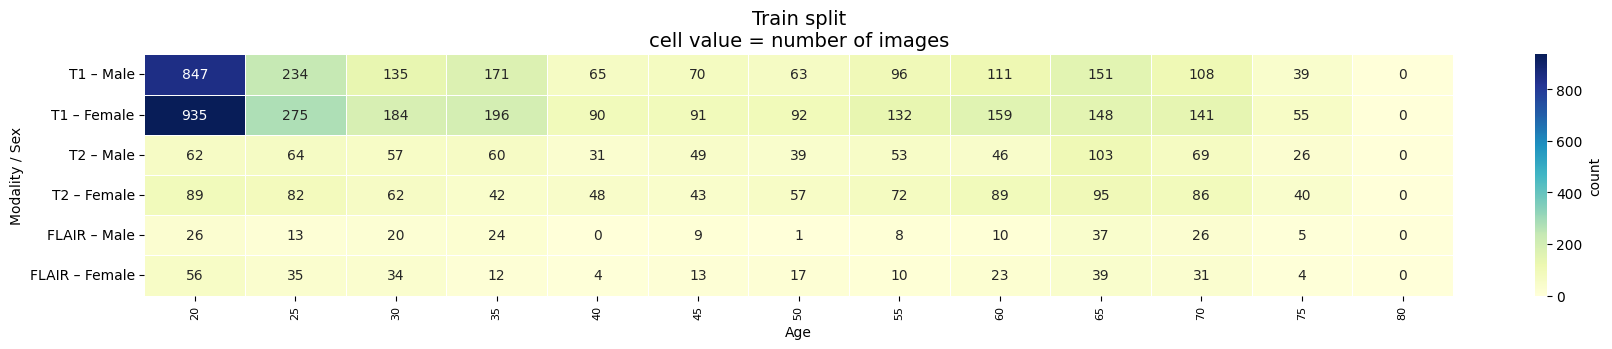

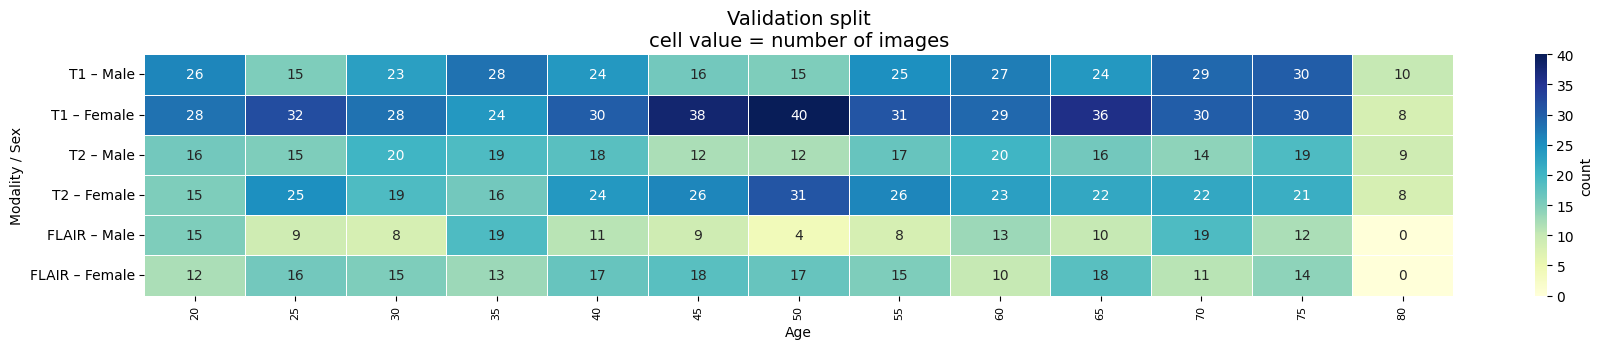

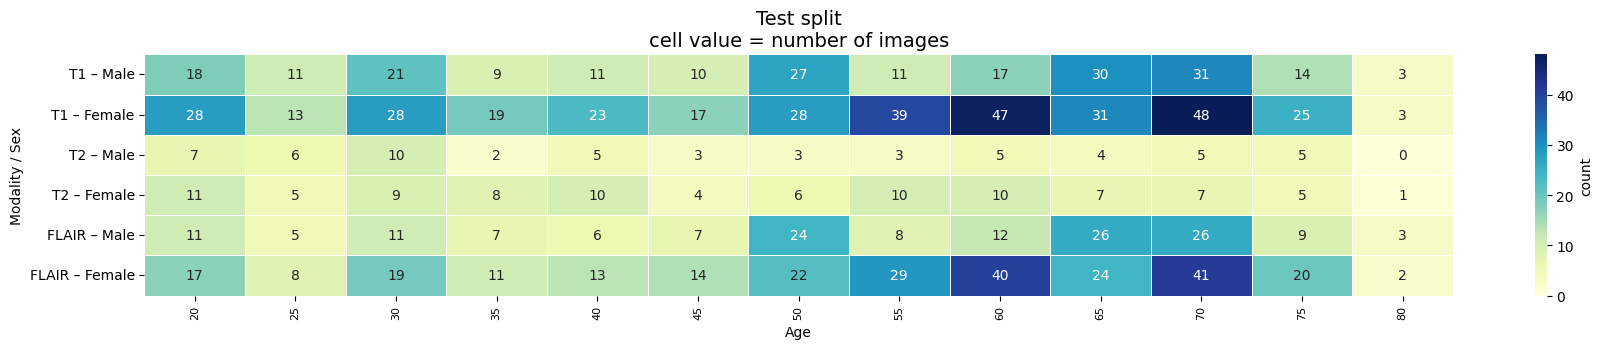

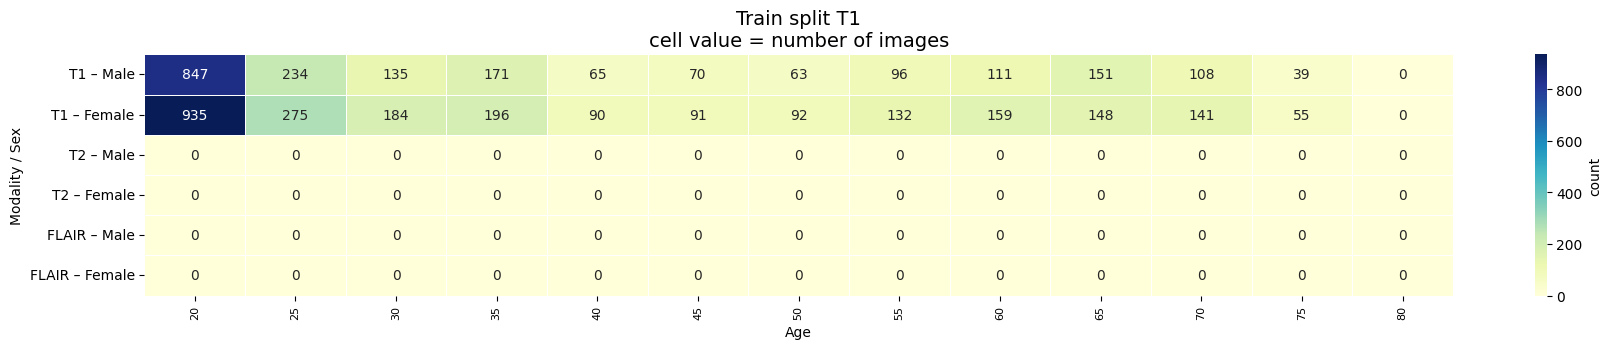

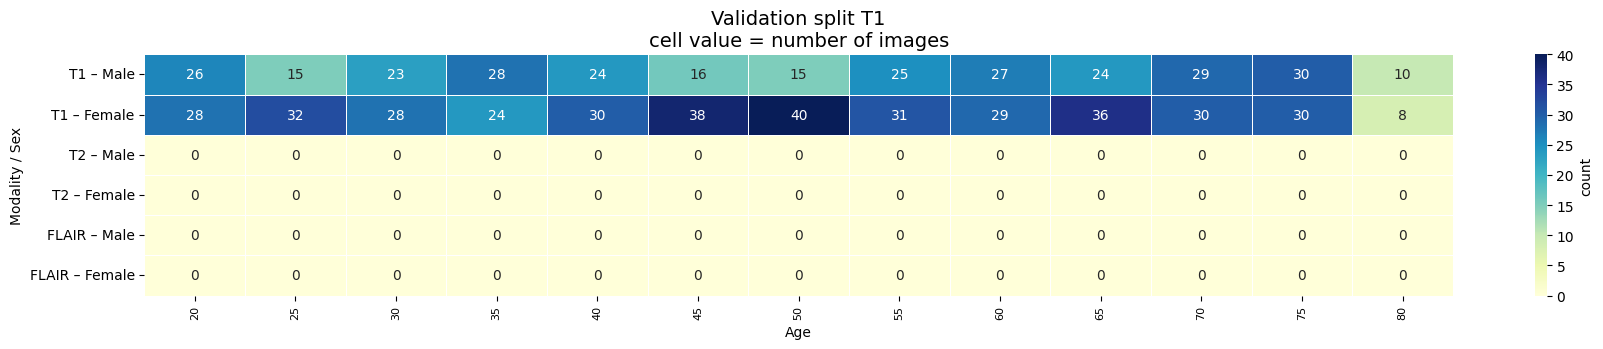

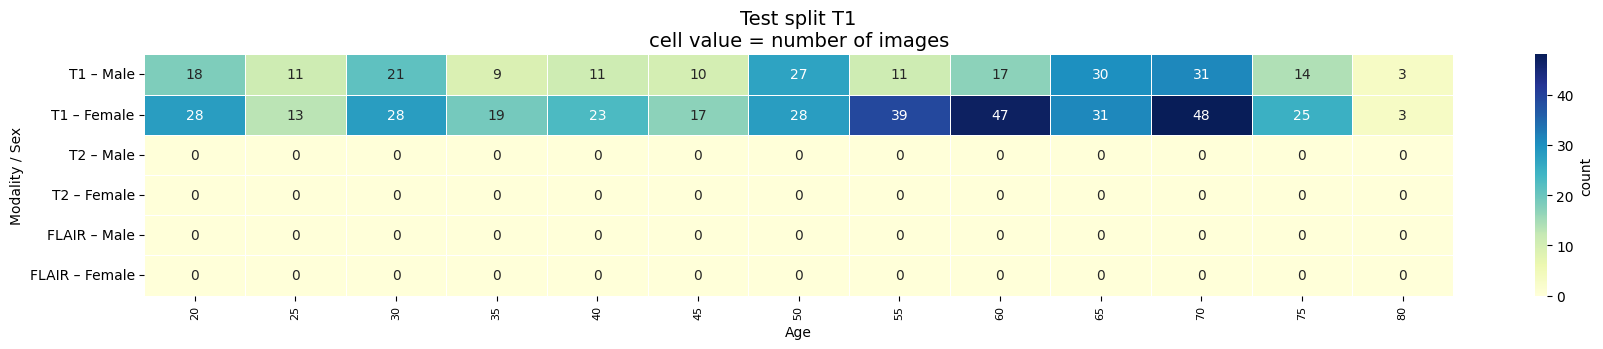

Saved heatmaps under ./plots/


In [44]:
# Generate heatmaps per dataset and for each split
os.makedirs('plots', exist_ok=True)

# # # # Per-dataset heatmaps across the full (kept) data
# for ds in sorted(df_all['dataset'].dropna().unique()):
#     sub = df_all[df_all['dataset'] == ds]
#     if len(sub) == 0:
#         continue
#     plot_count_heatmap(sub, title=f'Dataset: {ds}', group_by=5, cmap='YlGnBu', log_scale=False, save_as=f'plots/heatmap_{ds}.png')

# Split heatmaps
plot_count_heatmap(train_df, title='Train split', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_train.png')
plot_count_heatmap(val_df,   title='Validation split', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_val.png')
plot_count_heatmap(test_df,  title='Test split', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_test.png')

plot_count_heatmap(train_t1_df, title='Train split T1', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_train_t1.png')
plot_count_heatmap(val_t1_df,   title='Validation split T1', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_val_t1.png')
plot_count_heatmap(test_t1_df,  title='Test split T1', group_by=5, cmap='YlGnBu', log_scale=False, save_as='plots/heatmap_test_t1.png')

print("Saved heatmaps under ./plots/")



  TRAIN — per-dataset breakdown  (6509 images, 12 datasets)


,dataset,images,male,female,other_sex,male%,female%,age_min,age_max,age_mean,age_std,n_t1,n_t2,n_flair
0,aomic_id1000,911,439,472,0,48.2,51.8,20.000000,26.0000,22.8,1.7,911,0,0
1,atag,82,44,38,0,53.7,46.3,21.000000,74.0000,38.7,18.7,41,41,0
2,camcan,930,468,462,0,50.3,49.7,20.000000,79.0000,51.3,16.4,465,465,0
3,cbs,46,22,24,0,47.8,52.2,22.000000,36.0000,25.7,3.6,23,23,0
4,corr,1016,522,494,0,51.4,48.6,20.000000,79.0000,30.5,15.2,1016,0,0
5,ixi,873,389,484,0,44.6,55.4,20.167009,79.4141,48.2,16.3,438,435,0
6,narratives,227,92,135,0,40.5,59.5,20.000000,50.0000,23.2,4.3,227,0,0
7,nimh_rv,543,194,349,0,35.7,64.3,21.000000,71.0000,32.5,11.2,132,143,268
8,npc,114,52,62,0,45.6,54.4,20.000000,35.0000,26.4,4.3,57,57,0
9,oasis3,944,384,560,0,40.7,59.3,43.243800,79.6658,66.3,7.0,455,300,189


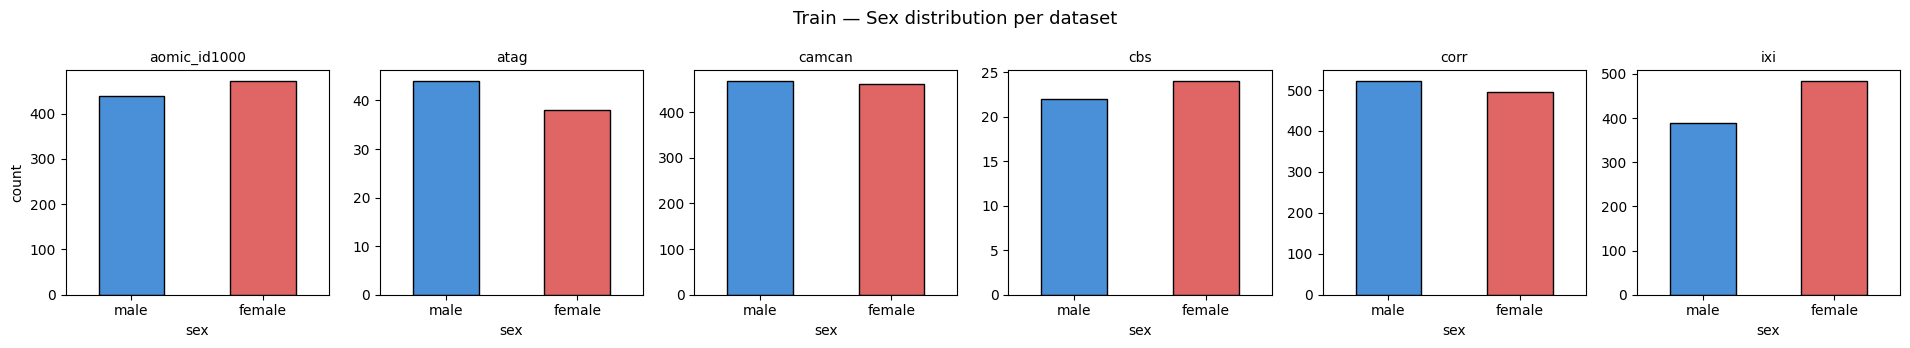

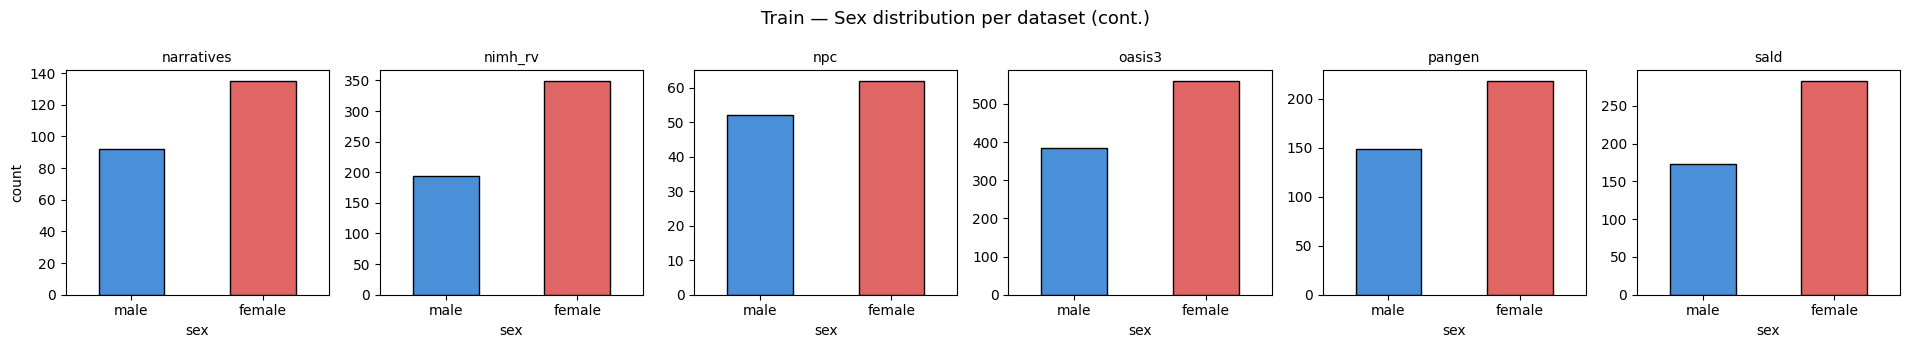

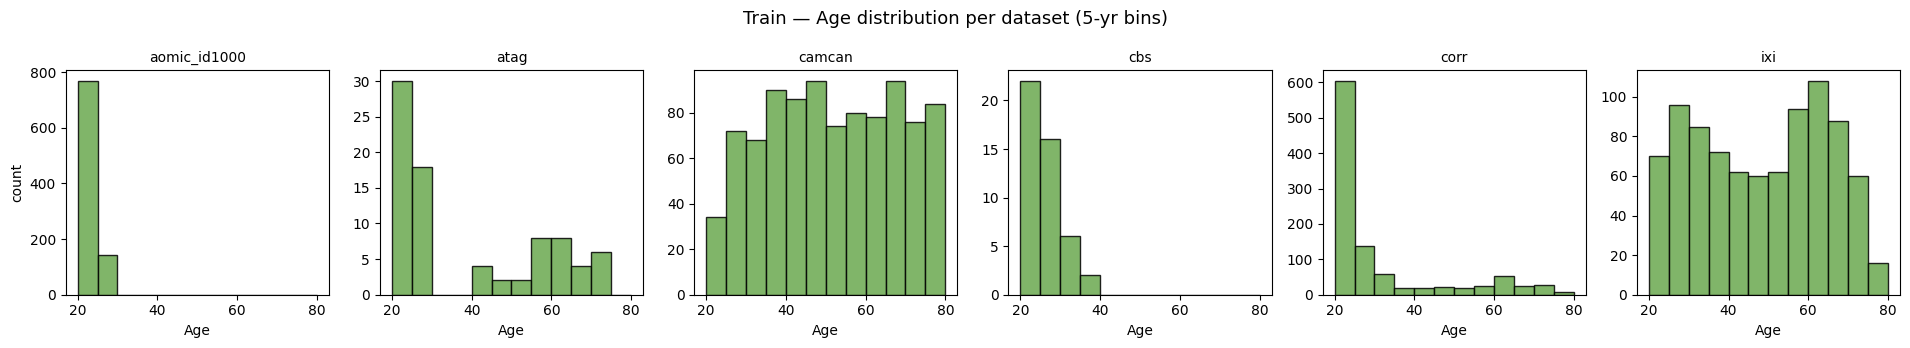

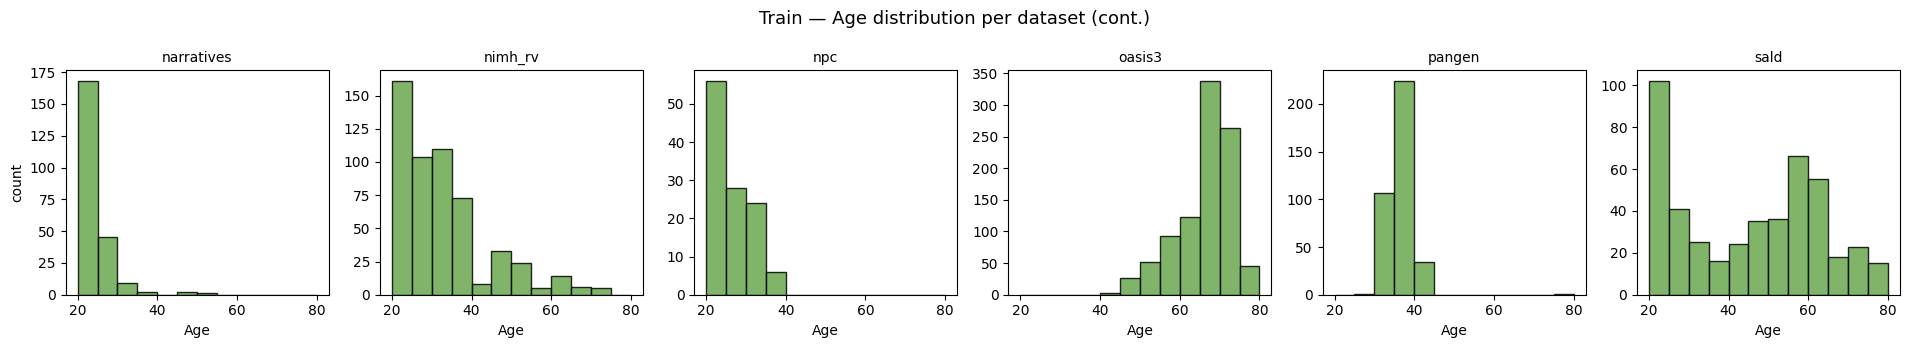

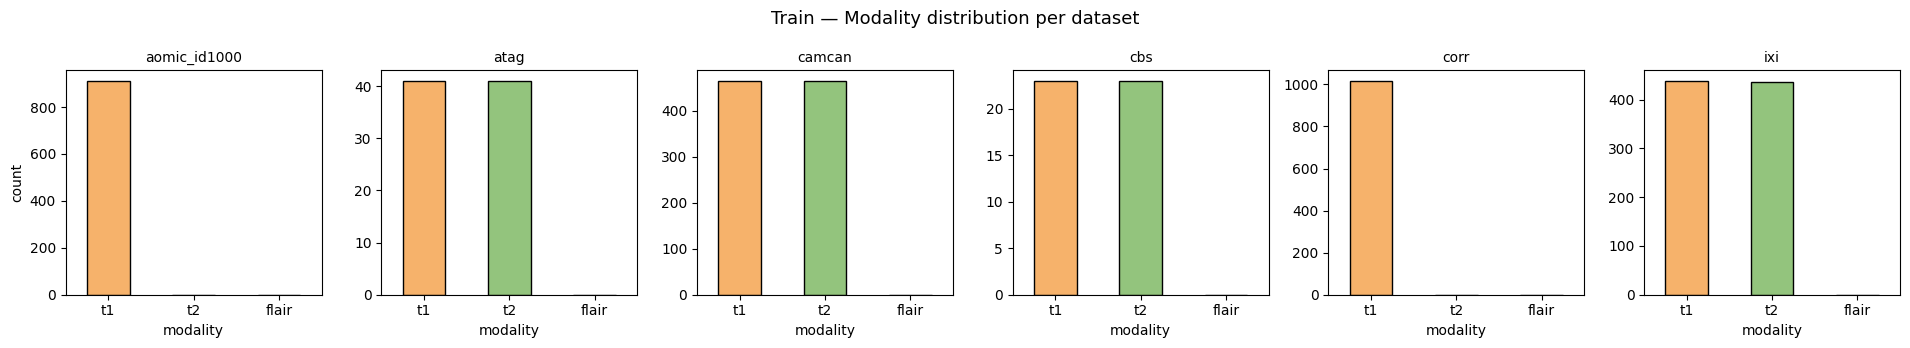

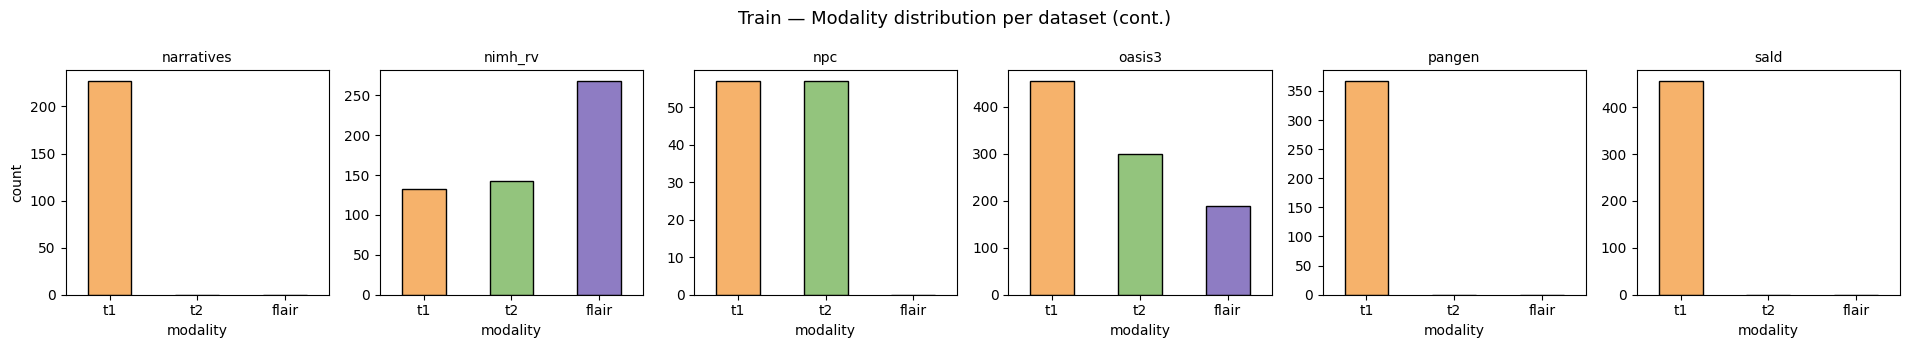


  VALIDATION — per-dataset breakdown  (1475 images, 12 datasets)


,dataset,images,male,female,other_sex,male%,female%,age_min,age_max,age_mean,age_std,n_t1,n_t2,n_flair
0,aomic_id1000,15,4,11,0,26.7,73.3,20.500000,26.000000,23.3,1.9,15,0,0
1,atag,20,14,6,0,70.0,30.0,23.000000,75.000000,44.6,18.6,10,10,0
2,camcan,268,122,146,0,45.5,54.5,20.000000,80.000000,57.3,18.4,134,134,0
3,cbs,10,4,6,0,40.0,60.0,21.000000,31.000000,26.8,4.3,5,5,0
4,corr,23,9,14,0,39.1,60.9,20.000000,79.000000,45.4,20.8,23,0,0
5,ixi,232,98,134,0,42.2,57.8,20.071184,78.584531,48.1,15.2,116,116,0
6,narratives,5,3,2,0,60.0,40.0,20.000000,53.000000,34.0,13.5,5,0,0
7,nimh_rv,385,160,225,0,41.6,58.4,20.000000,72.000000,37.0,10.8,107,98,180
8,npc,18,8,10,0,44.4,55.6,22.000000,33.000000,28.1,3.8,9,9,0
9,oasis3,439,188,251,0,42.8,57.2,42.498600,79.438400,65.2,9.0,193,113,133


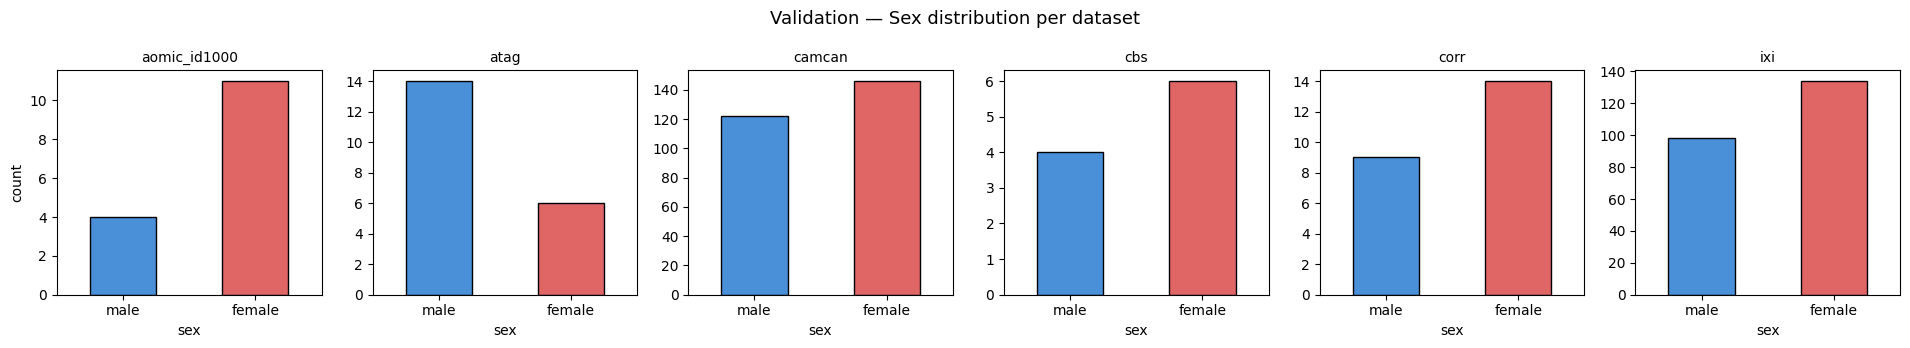

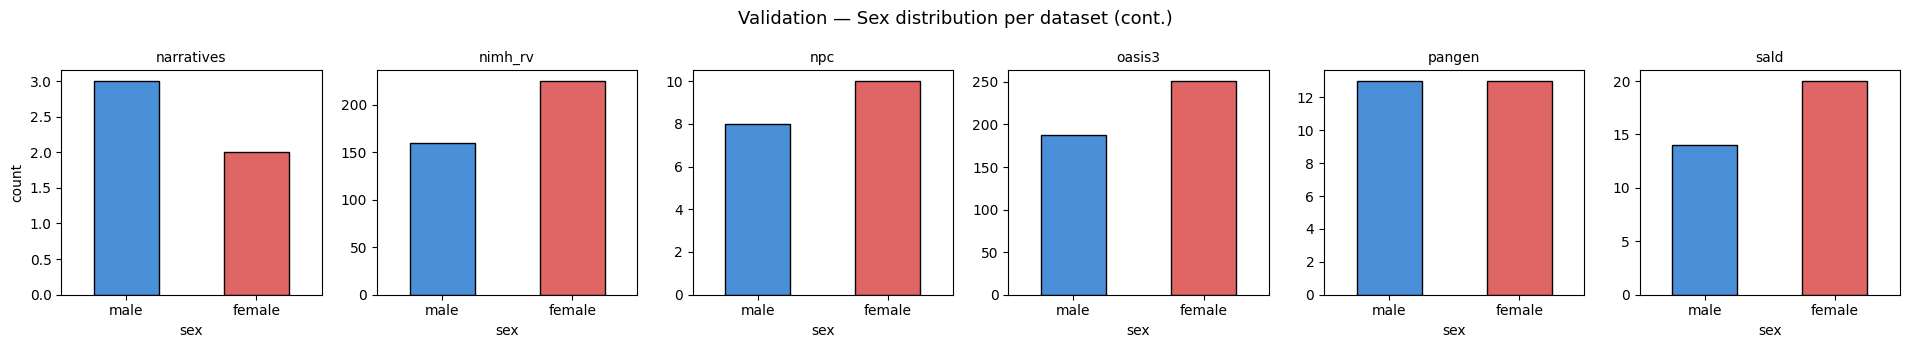

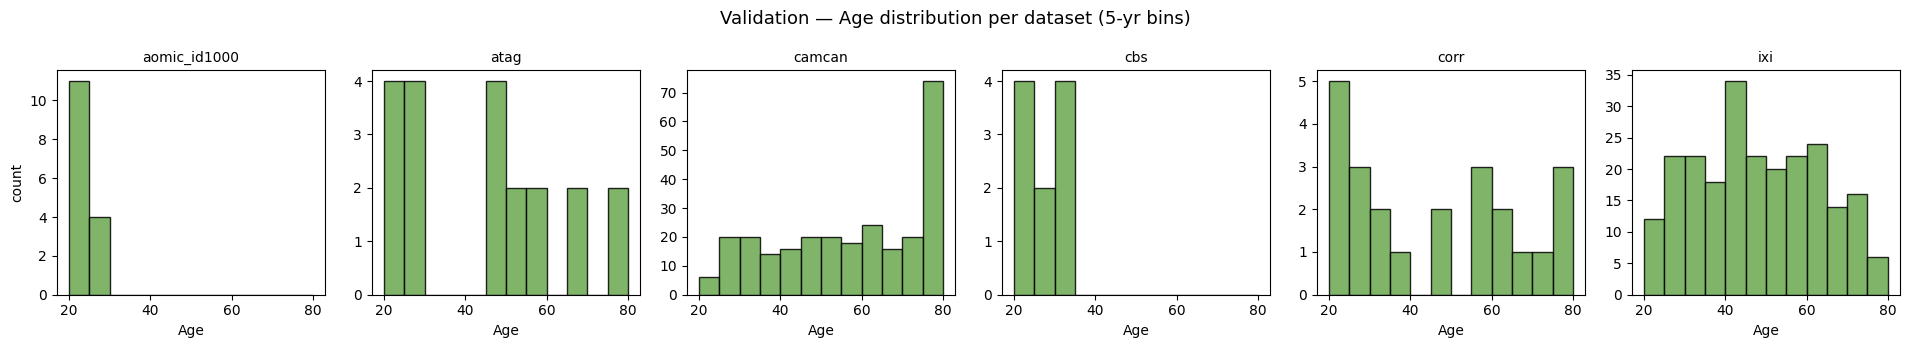

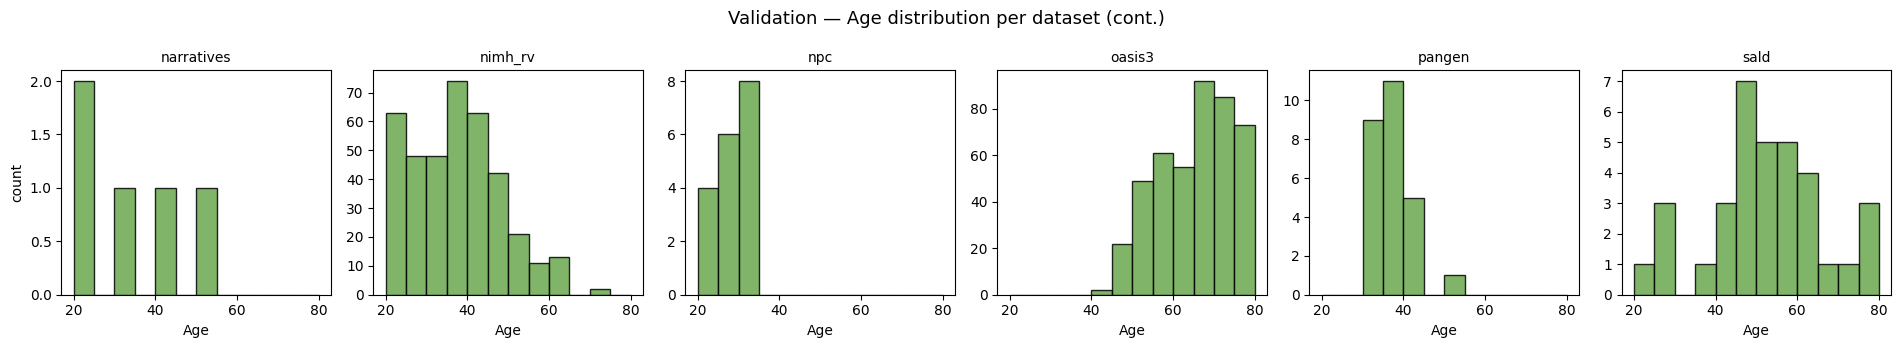

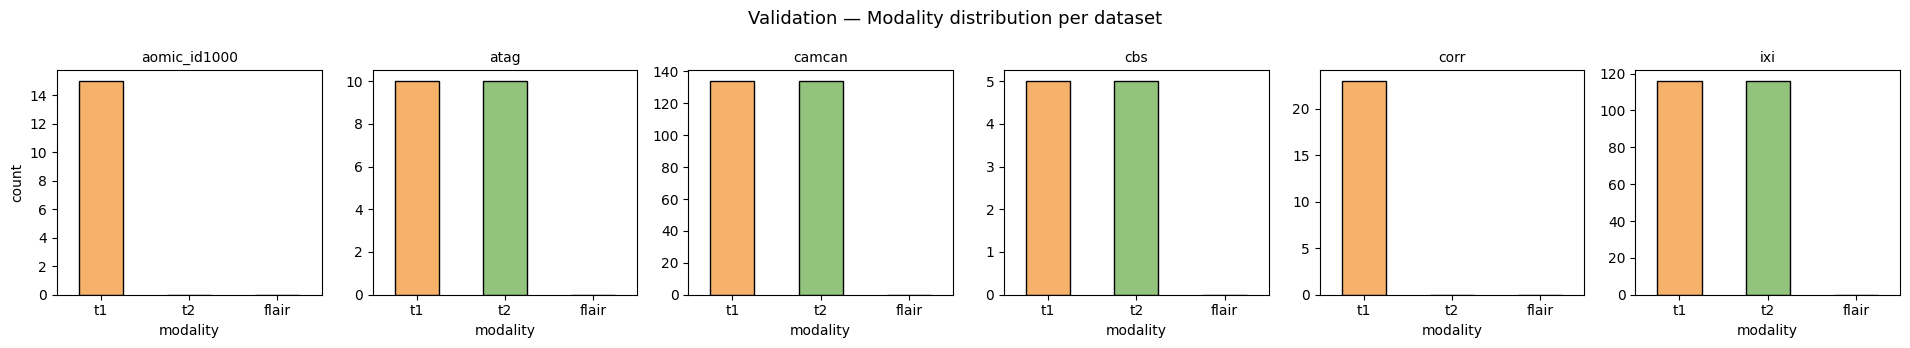

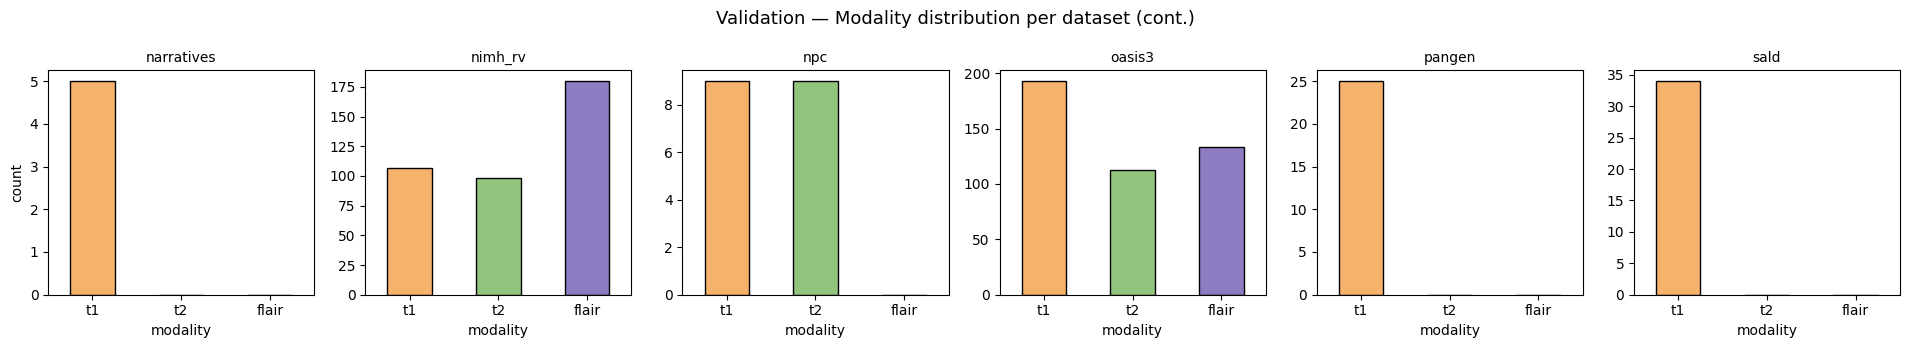


  TEST — per-dataset breakdown  (1128 images, 2 datasets)


,dataset,images,male,female,other_sex,male%,female%,age_min,age_max,age_mean,age_std,n_t1,n_t2,n_flair
0,boldvar,302,116,186,0,38.4,61.6,20.0,80.0,47.7,18.0,151,151,0
1,dallas_lifespan,826,310,516,0,37.5,62.5,21.0,80.0,55.1,16.5,411,0,415


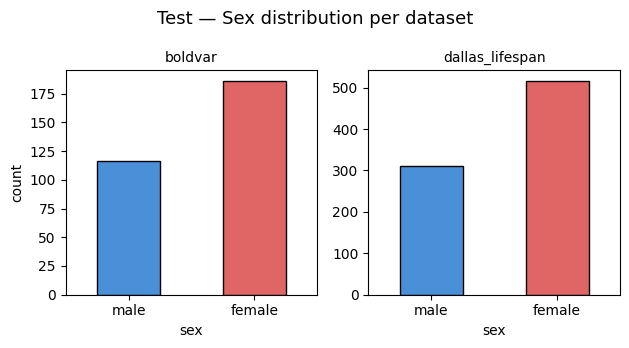

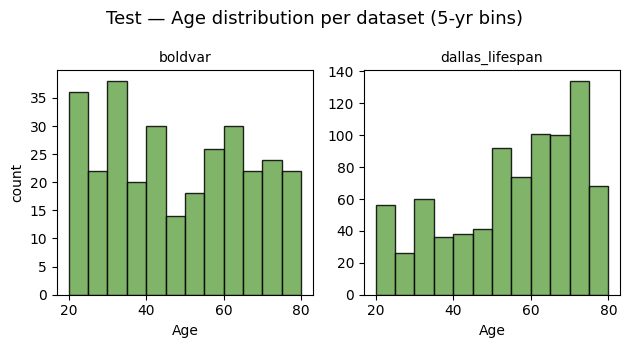

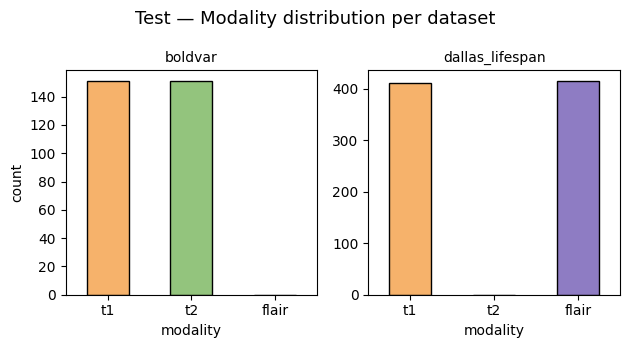

In [45]:
# ============================================================================
# PER-DATASET BREAKDOWN: sex, age & modality distributions per split
# ============================================================================

def dataset_breakdown(split_df: pd.DataFrame, split_name: str):
    """Print and plot sex / age / modality breakdown for every dataset in a split."""

    datasets = sorted(split_df['dataset'].dropna().unique())
    print(f"\n{'='*80}")
    print(f"  {split_name.upper()} — per-dataset breakdown  ({len(split_df)} images, "
          f"{len(datasets)} datasets)")
    print(f"{'='*80}")

    rows = []
    for ds in datasets:
        sub = split_df[split_df['dataset'] == ds]
        n = len(sub)
        n_male   = (sub['sex'] == 'male').sum()
        n_female = (sub['sex'] == 'female').sum()
        n_other  = n - n_male - n_female
        rows.append({
            'dataset':   ds,
            'images':    n,
            'male':      n_male,
            'female':    n_female,
            'other_sex': n_other,
            'male%':     round(100 * n_male / n, 1) if n else 0,
            'female%':   round(100 * n_female / n, 1) if n else 0,
            'age_min':   sub['age'].min(),
            'age_max':   sub['age'].max(),
            'age_mean':  round(sub['age'].mean(), 1),
            'age_std':   round(sub['age'].std(), 1),
            **{f'n_{m}': (sub['modality'] == m).sum() for m in MODALITIES},
        })
    summary = pd.DataFrame(rows)
    display(summary)

    # ---- plots ----
    n_ds = len(datasets)
    if n_ds == 0:
        return summary

    # 1) Sex distribution per dataset
    fig, axes = plt.subplots(1, min(n_ds, 6), figsize=(min(n_ds, 6) * 3.2, 3.5),
                             squeeze=False)
    axes = axes.flatten()
    for i, ds in enumerate(datasets[:6]):
        sub = split_df[split_df['dataset'] == ds]
        sub['sex'].value_counts().reindex(['male', 'female']).plot.bar(
            ax=axes[i], color=['#4a90d9', '#e06666'], edgecolor='black')
        axes[i].set_title(ds, fontsize=10)
        axes[i].set_ylabel('count' if i == 0 else '')
        axes[i].tick_params(axis='x', rotation=0)
    plt.suptitle(f'{split_name} — Sex distribution per dataset', fontsize=13)
    plt.tight_layout()
    plt.show()

    if n_ds > 6:   # second row if many datasets
        fig2, axes2 = plt.subplots(1, min(n_ds - 6, 6),
                                   figsize=(min(n_ds - 6, 6) * 3.2, 3.5), squeeze=False)
        axes2 = axes2.flatten()
        for i, ds in enumerate(datasets[6:12]):
            sub = split_df[split_df['dataset'] == ds]
            sub['sex'].value_counts().reindex(['male', 'female']).plot.bar(
                ax=axes2[i], color=['#4a90d9', '#e06666'], edgecolor='black')
            axes2[i].set_title(ds, fontsize=10)
            axes2[i].set_ylabel('count' if i == 0 else '')
            axes2[i].tick_params(axis='x', rotation=0)
        plt.suptitle(f'{split_name} — Sex distribution per dataset (cont.)', fontsize=13)
        plt.tight_layout()
        plt.show()

    # 2) Age distribution per dataset
    fig, axes = plt.subplots(1, min(n_ds, 6), figsize=(min(n_ds, 6) * 3.2, 3.5),
                             squeeze=False)
    axes = axes.flatten()
    for i, ds in enumerate(datasets[:6]):
        sub = split_df[split_df['dataset'] == ds]
        axes[i].hist(sub['age'], bins=range(AGE_MIN, AGE_MAX + 5, 5),
                     color='#6aa84f', edgecolor='black', alpha=0.85)
        axes[i].set_title(ds, fontsize=10)
        axes[i].set_xlabel('Age')
        axes[i].set_ylabel('count' if i == 0 else '')
    plt.suptitle(f'{split_name} — Age distribution per dataset (5-yr bins)', fontsize=13)
    plt.tight_layout()
    plt.show()

    if n_ds > 6:
        fig2, axes2 = plt.subplots(1, min(n_ds - 6, 6),
                                   figsize=(min(n_ds - 6, 6) * 3.2, 3.5), squeeze=False)
        axes2 = axes2.flatten()
        for i, ds in enumerate(datasets[6:12]):
            sub = split_df[split_df['dataset'] == ds]
            axes2[i].hist(sub['age'], bins=range(AGE_MIN, AGE_MAX + 5, 5),
                          color='#6aa84f', edgecolor='black', alpha=0.85)
            axes2[i].set_title(ds, fontsize=10)
            axes2[i].set_xlabel('Age')
            axes2[i].set_ylabel('count' if i == 0 else '')
        plt.suptitle(f'{split_name} — Age distribution per dataset (cont.)', fontsize=13)
        plt.tight_layout()
        plt.show()

    # 3) Modality distribution per dataset
    fig, axes = plt.subplots(1, min(n_ds, 6), figsize=(min(n_ds, 6) * 3.2, 3.5),
                             squeeze=False)
    axes = axes.flatten()
    mod_colors = {'t1': '#f6b26b', 't2': '#93c47d', 'flair': '#8e7cc3'}
    for i, ds in enumerate(datasets[:6]):
        sub = split_df[split_df['dataset'] == ds]
        counts = sub['modality'].value_counts().reindex(MODALITIES).fillna(0)
        counts.plot.bar(ax=axes[i],
                        color=[mod_colors.get(m, 'grey') for m in counts.index],
                        edgecolor='black')
        axes[i].set_title(ds, fontsize=10)
        axes[i].set_ylabel('count' if i == 0 else '')
        axes[i].tick_params(axis='x', rotation=0)
    plt.suptitle(f'{split_name} — Modality distribution per dataset', fontsize=13)
    plt.tight_layout()
    plt.show()

    if n_ds > 6:
        fig2, axes2 = plt.subplots(1, min(n_ds - 6, 6),
                                   figsize=(min(n_ds - 6, 6) * 3.2, 3.5), squeeze=False)
        axes2 = axes2.flatten()
        for i, ds in enumerate(datasets[6:12]):
            sub = split_df[split_df['dataset'] == ds]
            counts = sub['modality'].value_counts().reindex(MODALITIES).fillna(0)
            counts.plot.bar(ax=axes2[i],
                            color=[mod_colors.get(m, 'grey') for m in counts.index],
                            edgecolor='black')
            axes2[i].set_title(ds, fontsize=10)
            axes2[i].set_ylabel('count' if i == 0 else '')
            axes2[i].tick_params(axis='x', rotation=0)
        plt.suptitle(f'{split_name} — Modality distribution per dataset (cont.)', fontsize=13)
        plt.tight_layout()
        plt.show()

    return summary


# ---------- run for every split ----------
train_summary = dataset_breakdown(train_df, 'Train')
val_summary   = dataset_breakdown(val_df,   'Validation')
test_summary  = dataset_breakdown(test_df,  'Test')


In [46]:
# ============================================================================
# COMPREHENSIVE SPLIT ANALYSIS
# ============================================================================

import pandas as pd
import numpy as np

print("="*80)
print("COMPREHENSIVE DATASET ANALYSIS")
print("="*80)

# Helper function to analyze a split
def analyze_split(df, split_name, is_t1_only=False):
    """Comprehensive analysis of a data split"""
    
    if len(df) == 0:
        print(f"\n{split_name}: EMPTY")
        return
    
    # Create unique subject ID
    df_temp = df.copy()
    df_temp['unique_subject_id'] = df_temp['dataset'] + '_' + df_temp['subject_id']
    
    suffix = " (T1 only)" if is_t1_only else ""
    print(f"\n{'─'*80}")
    print(f"{split_name.upper()}{suffix}")
    print(f"{'─'*80}")
    
    # Basic counts
    n_images = len(df_temp)
    n_subjects = df_temp['unique_subject_id'].nunique()
    n_datasets = df_temp['dataset'].nunique()
    
    print(f"\n📊 BASIC COUNTS:")
    print(f"   Total images:        {n_images:>6,}")
    print(f"   Unique subjects:     {n_subjects:>6,}")
    print(f"   Datasets:            {n_datasets:>6}")
    print(f"   Images per subject:  {n_images/n_subjects:>6.2f}")
    
    # Dataset distribution
    print(f"\n📁 DATASET DISTRIBUTION:")
    dataset_counts = df_temp['dataset'].value_counts().sort_index()
    for ds, count in dataset_counts.items():
        pct = 100 * count / n_images
        n_subj = df_temp[df_temp['dataset'] == ds]['unique_subject_id'].nunique()
        print(f"   {ds:<20} {count:>5,} images ({pct:>5.1f}%) | {n_subj:>4,} subjects")
    
    # Modality distribution
    if not is_t1_only:
        print(f"\n🔬 MODALITY DISTRIBUTION:")
        modality_counts = df_temp['modality'].value_counts().sort_index()
        for mod, count in modality_counts.items():
            pct = 100 * count / n_images
            n_subj = df_temp[df_temp['modality'] == mod]['unique_subject_id'].nunique()
            print(f"   {str(mod).upper():<10} {count:>5,} images ({pct:>5.1f}%) | {n_subj:>4,} subjects")
    
    # Sex distribution
    print(f"\n⚥ SEX DISTRIBUTION:")
    sex_counts = df_temp['sex'].value_counts().sort_index()
    for sex, count in sex_counts.items():
        pct = 100 * count / n_images
        print(f"   {str(sex).capitalize():<10} {count:>5,} images ({pct:>5.1f}%)")
    
    # Age statistics
    print(f"\n📅 AGE STATISTICS:")
    print(f"   Min age:             {df_temp['age'].min():>6.1f}")
    print(f"   Max age:             {df_temp['age'].max():>6.1f}")
    print(f"   Mean age:            {df_temp['age'].mean():>6.1f} ± {df_temp['age'].std():.1f}")
    print(f"   Median age:          {df_temp['age'].median():>6.1f}")
    
    # Age bin distribution (5-year bins)
    print(f"\n📊 AGE DISTRIBUTION (5-year bins):")
    age_bin_counts = df_temp['5_age_bin'].value_counts().sort_index()
    for age_bin, count in age_bin_counts.items():
        pct = 100 * count / n_images
        print(f"   {int(age_bin)}-{int(age_bin)+4:>2} years: {count:>5,} images ({pct:>5.1f}%)")
    
    # Multi-image subjects
    subject_image_counts = df_temp['unique_subject_id'].value_counts()
    multi_image_subjects = (subject_image_counts > 1).sum()
    max_images_per_subject = subject_image_counts.max()
    
    print(f"\n🔄 MULTI-IMAGE SUBJECTS:")
    print(f"   Subjects with 1 image:     {(subject_image_counts == 1).sum():>5,}")
    print(f"   Subjects with >1 images:   {multi_image_subjects:>5,}")
    print(f"   Max images per subject:    {max_images_per_subject:>5}")
    
    # Show top multi-image subjects
    if multi_image_subjects > 0:
        top_subjects = subject_image_counts.head(5)
        print(f"   Top subjects by image count:")
        for subj, count in top_subjects.items():
            if count > 1:
                print(f"      {subj}: {count} images")
    
    return df_temp['unique_subject_id'].unique()


# ============================================================================
# ANALYZE EACH SPLIT
# ============================================================================

# Full datasets
train_subjects = analyze_split(train_df, "TRAIN", is_t1_only=False)
val_subjects = analyze_split(val_df, "VALIDATION", is_t1_only=False)
test_subjects = analyze_split(test_df, "TEST", is_t1_only=False)

# T1-only datasets
train_t1_subjects = analyze_split(train_t1_df, "TRAIN", is_t1_only=True)
val_t1_subjects = analyze_split(val_t1_df, "VALIDATION", is_t1_only=True)
test_t1_subjects = analyze_split(test_t1_df, "TEST", is_t1_only=True)


# ============================================================================
# OVERLAP ANALYSIS
# ============================================================================

print(f"\n{'='*80}")
print("SUBJECT OVERLAP ANALYSIS")
print(f"{'='*80}")

train_set = set(train_subjects)
val_set = set(val_subjects)
test_set = set(test_subjects)

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print(f"\n🔍 FULL DATASET OVERLAPS:")
print(f"   Train unique subjects:     {len(train_set):>6,}")
print(f"   Val unique subjects:       {len(val_set):>6,}")
print(f"   Test unique subjects:      {len(test_set):>6,}")
print(f"\n   Train ∩ Val overlap:       {len(train_val_overlap):>6,} {'✅ GOOD' if len(train_val_overlap) == 0 else '⚠️ LEAKAGE!'}")
print(f"   Train ∩ Test overlap:      {len(train_test_overlap):>6,} {'✅ GOOD' if len(train_test_overlap) == 0 else '⚠️ LEAKAGE!'}")
print(f"   Val ∩ Test overlap:        {len(val_test_overlap):>6,} {'✅ GOOD' if len(val_test_overlap) == 0 else '⚠️ LEAKAGE!'}")

if train_val_overlap:
    print(f"\n   ⚠️ Train-Val overlapping subjects (first 10):")
    for subj in list(train_val_overlap)[:10]:
        print(f"      {subj}")

if train_test_overlap:
    print(f"\n   ⚠️ Train-Test overlapping subjects (first 10):")
    for subj in list(train_test_overlap)[:10]:
        print(f"      {subj}")

if val_test_overlap:
    print(f"\n   ⚠️ Val-Test overlapping subjects (first 10):")
    for subj in list(val_test_overlap)[:10]:
        print(f"      {subj}")

# T1-only overlaps
train_t1_set = set(train_t1_subjects)
val_t1_set = set(val_t1_subjects)
test_t1_set = set(test_t1_subjects)

train_val_t1_overlap = train_t1_set & val_t1_set
train_test_t1_overlap = train_t1_set & test_t1_set
val_test_t1_overlap = val_t1_set & test_t1_set

print(f"\n🔍 T1-ONLY DATASET OVERLAPS:")
print(f"   Train unique subjects:     {len(train_t1_set):>6,}")
print(f"   Val unique subjects:       {len(val_t1_set):>6,}")
print(f"   Test unique subjects:      {len(test_t1_set):>6,}")
print(f"\n   Train ∩ Val overlap:       {len(train_val_t1_overlap):>6,} {'✅ GOOD' if len(train_val_t1_overlap) == 0 else '⚠️ LEAKAGE!'}")
print(f"   Train ∩ Test overlap:      {len(train_test_t1_overlap):>6,} {'✅ GOOD' if len(train_test_t1_overlap) == 0 else '⚠️ LEAKAGE!'}")
print(f"   Val ∩ Test overlap:        {len(val_test_t1_overlap):>6,} {'✅ GOOD' if len(val_test_t1_overlap) == 0 else '⚠️ LEAKAGE!'}")


# ============================================================================
# SPLIT PROPORTIONS
# ============================================================================

print(f"\n{'='*80}")
print("SPLIT PROPORTIONS")
print(f"{'='*80}")

total_images = len(train_df) + len(val_df) + len(test_df)
total_t1_images = len(train_t1_df) + len(val_t1_df) + len(test_t1_df)

print(f"\n📊 FULL DATASET:")
print(f"   Total images:              {total_images:>6,}")
print(f"   Train:   {len(train_df):>6,} images ({100*len(train_df)/total_images:>5.1f}%)")
print(f"   Val:     {len(val_df):>6,} images ({100*len(val_df)/total_images:>5.1f}%)")
print(f"   Test:    {len(test_df):>6,} images ({100*len(test_df)/total_images:>5.1f}%)")

print(f"\n📊 T1-ONLY DATASET:")
print(f"   Total images:              {total_t1_images:>6,}")
print(f"   Train:   {len(train_t1_df):>6,} images ({100*len(train_t1_df)/total_t1_images:>5.1f}%)")
print(f"   Val:     {len(val_t1_df):>6,} images ({100*len(val_t1_df)/total_t1_images:>5.1f}%)")
print(f"   Test:    {len(test_t1_df):>6,} images ({100*len(test_t1_df)/total_t1_images:>5.1f}%)")


# ============================================================================
# VALIDATION TARGET vs ACTUAL
# ============================================================================

print(f"\n{'='*80}")
print("VALIDATION SIZE ANALYSIS")
print(f"{'='*80}")

train_pool_size = len(train_df) + len(val_df)
target_val_size = int(train_pool_size * VAL_FRACTION)
actual_val_size = len(val_df)
actual_val_pct = 100 * actual_val_size / train_pool_size

print(f"\n🎯 TARGET vs ACTUAL:")
print(f"   Train pool size:           {train_pool_size:>6,} images")
print(f"   Target val fraction:       {VAL_FRACTION*100:>6.1f}%")
print(f"   Target val size:           {target_val_size:>6,} images")
print(f"   Target per group:          {VAL_PER_GROUP:>6} images")
print(f"\n   Actual val size:           {actual_val_size:>6,} images")
print(f"   Actual val fraction:       {actual_val_pct:>6.1f}%")
print(f"   Difference:                {actual_val_size - target_val_size:>+6,} images")

# Calculate group counts
val_temp = val_df.copy()
val_temp['unique_subject_id'] = val_temp['dataset'] + '_' + val_temp['subject_id']
group_counts = val_df.groupby(['5_age_bin', 'modality']).size().reset_index(name='count')

print(f"\n📊 VALIDATION DISTRIBUTION PER (AGE_BIN, MODALITY):")
print(f"   Number of groups:          {len(group_counts)}")
print(f"   Mean images per group:     {group_counts['count'].mean():>6.1f}")
print(f"   Median images per group:   {group_counts['count'].median():>6.1f}")
print(f"   Min images per group:      {group_counts['count'].min():>6}")
print(f"   Max images per group:      {group_counts['count'].max():>6}")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}\n")

COMPREHENSIVE DATASET ANALYSIS

────────────────────────────────────────────────────────────────────────────────
TRAIN
────────────────────────────────────────────────────────────────────────────────

📊 BASIC COUNTS:
   Total images:         6,509
   Unique subjects:      4,599
   Datasets:                12
   Images per subject:    1.42

📁 DATASET DISTRIBUTION:
   aomic_id1000           911 images ( 14.0%) |  911 subjects
   atag                    82 images (  1.3%) |   41 subjects
   camcan                 930 images ( 14.3%) |  465 subjects
   cbs                     46 images (  0.7%) |   23 subjects
   corr                 1,016 images ( 15.6%) | 1,016 subjects
   ixi                    873 images ( 13.4%) |  439 subjects
   narratives             227 images (  3.5%) |  227 subjects
   nimh_rv                543 images (  8.3%) |  142 subjects
   npc                    114 images (  1.8%) |   57 subjects
   oasis3                 944 images ( 14.5%) |  455 subjects
   pangen    

In [47]:
# ============================================================================
# DIAGNOSTIC: WHY NAN MAE AND R2 DURING VALIDATION?
# ============================================================================

import pandas as pd
import numpy as np
import os
from pathlib import Path

print("="*80)
print("🔍 VALIDATION DATA DIAGNOSTICS - NaN MAE/R² Investigation")
print("="*80)

# Define the base path for images (adjust if needed)
BASE_DATA_PATH = Path(r"C:\Projects\thesis_project\Data\brain_age_preprocessed_no_csf")

def check_split_data(df, split_name, check_files=True):
    """Comprehensive diagnostic check for a data split"""
    
    print(f"\n{'─'*80}")
    print(f"CHECKING {split_name.upper()} SPLIT")
    print(f"{'─'*80}")
    
    # 1. Check for NaN/Inf in age labels
    print(f"\n1️⃣ LABEL VALIDITY CHECK:")
    print(f"   Total rows: {len(df)}")
    
    nan_ages = df['age'].isna().sum()
    inf_ages = np.isinf(df['age']).sum() if df['age'].dtype in [np.float32, np.float64] else 0
    negative_ages = (df['age'] < 0).sum()
    extreme_ages = ((df['age'] < 0) | (df['age'] > 150)).sum()
    
    print(f"   NaN ages: {nan_ages} {'❌ PROBLEM!' if nan_ages > 0 else '✅'}")
    print(f"   Inf ages: {inf_ages} {'❌ PROBLEM!' if inf_ages > 0 else '✅'}")
    print(f"   Negative ages: {negative_ages} {'❌ PROBLEM!' if negative_ages > 0 else '✅'}")
    print(f"   Extreme ages (<0 or >150): {extreme_ages} {'❌ PROBLEM!' if extreme_ages > 0 else '✅'}")
    
    if nan_ages > 0:
        print(f"\n   ⚠️ Rows with NaN ages:")
        print(df[df['age'].isna()][['subject_id', 'image_path', 'age']].head(10))
    
    if inf_ages > 0:
        print(f"\n   ⚠️ Rows with Inf ages:")
        print(df[np.isinf(df['age'])][['subject_id', 'image_path', 'age']].head(10))
    
    # 2. Check age statistics
    print(f"\n2️⃣ AGE STATISTICS:")
    valid_ages = df['age'].dropna()
    if len(valid_ages) > 0:
        print(f"   Min: {valid_ages.min():.2f}")
        print(f"   Max: {valid_ages.max():.2f}")
        print(f"   Mean: {valid_ages.mean():.2f} ± {valid_ages.std():.2f}")
        print(f"   Median: {valid_ages.median():.2f}")
        print(f"   Variance: {valid_ages.var():.2f} {'⚠️ Zero variance!' if valid_ages.var() == 0 else '✅'}")
    else:
        print(f"   ❌ No valid ages found!")
    
    # 3. Check for missing/duplicate image paths
    print(f"\n3️⃣ IMAGE PATH CHECK:")
    null_paths = df['image_path'].isna().sum()
    empty_paths = (df['image_path'].str.strip() == '').sum()
    duplicate_paths = df['image_path'].duplicated().sum()
    
    print(f"   Null paths: {null_paths} {'❌ PROBLEM!' if null_paths > 0 else '✅'}")
    print(f"   Empty paths: {empty_paths} {'❌ PROBLEM!' if empty_paths > 0 else '✅'}")
    print(f"   Duplicate paths: {duplicate_paths} {'⚠️ Warning' if duplicate_paths > 0 else '✅'}")
    
    if duplicate_paths > 0:
        print(f"\n   First 5 duplicate paths:")
        dup_paths = df[df['image_path'].duplicated(keep=False)]['image_path'].unique()[:5]
        for path in dup_paths:
            count = (df['image_path'] == path).sum()
            print(f"      {path} (appears {count} times)")
    
    # 4. Check if files actually exist
    if check_files and len(df) > 0:
        print(f"\n4️⃣ FILE EXISTENCE CHECK (sampling first 100 files):")
        sample_size = min(100, len(df))
        sample_df = df.head(sample_size)
        
        existing_files = 0
        missing_files = 0
        missing_file_list = []
        
        for idx, row in sample_df.iterrows():
            full_path = BASE_DATA_PATH / row['image_path']
            if full_path.exists():
                existing_files += 1
            else:
                missing_files += 1
                if len(missing_file_list) < 10:
                    missing_file_list.append(str(full_path))
        
        print(f"   Files checked: {sample_size}")
        print(f"   Existing: {existing_files} ({100*existing_files/sample_size:.1f}%)")
        print(f"   Missing: {missing_files} ({100*missing_files/sample_size:.1f}%) {'❌ PROBLEM!' if missing_files > 0 else '✅'}")
        
        if missing_files > 0:
            print(f"\n   ⚠️ First {len(missing_file_list)} missing files:")
            for path in missing_file_list:
                print(f"      {path}")
    
    # 5. Check for NaN in frequency weights
    print(f"\n5️⃣ SAMPLING WEIGHT CHECK:")
    nan_age_freq = df['age_frequency'].isna().sum()
    nan_age_mod_freq = df['age_modality_frequency'].isna().sum()
    inf_age_freq = np.isinf(df['age_frequency']).sum() if df['age_frequency'].dtype in [np.float32, np.float64] else 0
    inf_age_mod_freq = np.isinf(df['age_modality_frequency']).sum() if df['age_modality_frequency'].dtype in [np.float32, np.float64] else 0
    
    print(f"   NaN in age_frequency: {nan_age_freq} {'❌ PROBLEM!' if nan_age_freq > 0 else '✅'}")
    print(f"   NaN in age_modality_frequency: {nan_age_mod_freq} {'❌ PROBLEM!' if nan_age_mod_freq > 0 else '✅'}")
    print(f"   Inf in age_frequency: {inf_age_freq} {'❌ PROBLEM!' if inf_age_freq > 0 else '✅'}")
    print(f"   Inf in age_modality_frequency: {inf_age_mod_freq} {'❌ PROBLEM!' if inf_age_mod_freq > 0 else '✅'}")
    
    if nan_age_freq > 0 or nan_age_mod_freq > 0:
        print(f"\n   Rows with NaN frequencies:")
        mask = df['age_frequency'].isna() | df['age_modality_frequency'].isna()
        print(df[mask][['subject_id', 'age', 'modality', 'age_frequency', 'age_modality_frequency']].head(10))
    
    # 6. Check modality distribution
    print(f"\n6️⃣ MODALITY DISTRIBUTION:")
    modality_counts = df['modality'].value_counts()
    for mod, count in modality_counts.items():
        print(f"   {mod}: {count} images")
    
    # 7. Check for potential data loading issues
    print(f"\n7️⃣ POTENTIAL DATA LOADING ISSUES:")
    
    # Check for subjects with only one modality
    df_temp = df.copy()
    df_temp['unique_subject_id'] = df_temp['dataset'] + '_' + df_temp['subject_id']
    subject_modality_counts = df_temp.groupby('unique_subject_id')['modality'].nunique()
    single_modality_subjects = (subject_modality_counts == 1).sum()
    
    print(f"   Subjects with single modality: {single_modality_subjects}")
    print(f"   Subjects with multiple modalities: {(subject_modality_counts > 1).sum()}")
    
    return df


# ============================================================================
# Run diagnostics on all splits
# ============================================================================

# Check validation set (most important for your NaN issue)
val_df_checked = check_split_data(val_df, "VALIDATION", check_files=True)

# Also check train and test for completeness
train_df_checked = check_split_data(train_df, "TRAIN", check_files=False)
test_df_checked = check_split_data(test_df, "TEST", check_files=False)


# ============================================================================
# Additional checks specific to NaN MAE/R² issues
# ============================================================================

print(f"\n{'='*80}")
print("🎯 SPECIFIC CHECKS FOR NaN MAE/R² DURING TRAINING")
print(f"{'='*80}")

print(f"\n✓ Common causes of NaN MAE/R² during validation:")
print(f"   1. NaN or Inf values in validation labels (ages)")
print(f"   2. Missing or corrupted image files that fail to load")
print(f"   3. All predictions are NaN due to model/data issues")
print(f"   4. Zero variance in targets (all same age)")
print(f"   5. Batch contains only NaN values")
print(f"   6. Data preprocessing issues (e.g., normalization by zero)")
print(f"   7. File path mismatch (wrong base directory)")

print(f"\n📋 SUMMARY OF ISSUES FOUND:")

issues_found = []

# Check validation set specifically
if val_df['age'].isna().any():
    issues_found.append("✗ NaN values in validation ages")
if np.isinf(val_df['age']).any():
    issues_found.append("✗ Inf values in validation ages")
if (val_df['age'] < 0).any():
    issues_found.append("✗ Negative ages in validation set")
if val_df['age'].var() == 0:
    issues_found.append("✗ Zero variance in validation ages")
if val_df['image_path'].isna().any():
    issues_found.append("✗ Missing image paths in validation set")
if (val_df['image_path'].str.strip() == '').any():
    issues_found.append("✗ Empty image paths in validation set")

if len(issues_found) == 0:
    print(f"   ✅ No obvious issues found in validation data!")
    print(f"\n   💡 If you're still getting NaN MAE/R², check:")
    print(f"      - Model output: are predictions NaN?")
    print(f"      - Data loading: are images loading correctly?")
    print(f"      - Preprocessing: normalization issues?")
    print(f"      - Base path: is BASE_DATA_PATH correct?")
    print(f"      - File format: can nibabel/sitk read your .nii.gz files?")
else:
    print(f"   ❌ ISSUES DETECTED:")
    for issue in issues_found:
        print(f"      {issue}")

print(f"\n💡 RECOMMENDED ACTIONS:")
print(f"   1. Fix any data issues identified above")
print(f"   2. Verify BASE_DATA_PATH points to correct directory")
print(f"   3. Try loading one validation image manually to test data pipeline")
print(f"   4. Add debugging in training loop to check prediction values")
print(f"   5. Check if loss becomes NaN before metrics do")

print(f"\n{'='*80}")
print("DIAGNOSTIC COMPLETE")
print(f"{'='*80}\n")


🔍 VALIDATION DATA DIAGNOSTICS - NaN MAE/R² Investigation

────────────────────────────────────────────────────────────────────────────────
CHECKING VALIDATION SPLIT
────────────────────────────────────────────────────────────────────────────────

1️⃣ LABEL VALIDITY CHECK:
   Total rows: 1475
   NaN ages: 0 ✅
   Inf ages: 0 ✅
   Negative ages: 0 ✅
   Extreme ages (<0 or >150): 0 ✅

2️⃣ AGE STATISTICS:
   Min: 20.00
   Max: 80.00
   Mean: 51.06 ± 17.66
   Median: 52.00
   Variance: 312.00 ✅

3️⃣ IMAGE PATH CHECK:
   Null paths: 0 ✅
   Empty paths: 0 ✅
   Duplicate paths: 0 ✅

4️⃣ FILE EXISTENCE CHECK (sampling first 100 files):
   Files checked: 100
   Existing: 63 (63.0%)
   Missing: 37 (37.0%) ❌ PROBLEM!

   ⚠️ First 10 missing files:
      C:\Projects\thesis_project\Data\brain_age_preprocessed_no_csf\OASIS\OASIS3\sub-OAS30429_ses-d0055_FLAIR.nii.gz
      C:\Projects\thesis_project\Data\brain_age_preprocessed_no_csf\OASIS\OASIS3\sub-OAS30429_ses-d0055_T1w.nii.gz
      C:\Projects\thesi

In [48]:
# ============================================================================
# DETAILED INVESTIGATION: MISSING FILES & MODALITY ISSUES
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("="*80)
print("🔎 DETAILED INVESTIGATION OF IDENTIFIED ISSUES")
print("="*80)

BASE_DATA_PATH = Path(r"C:\Projects\thesis_project\Data\brain_age_preprocessed")

# ============================================================================
# 1. CHECK FOR EMPTY MODALITY
# ============================================================================

print("\n" + "─"*80)
print("1️⃣ EMPTY MODALITY INVESTIGATION")
print("─"*80)

empty_modality_val = val_df[val_df['modality'].isna() | (val_df['modality'] == '')]
empty_modality_train = train_df[train_df['modality'].isna() | (train_df['modality'] == '')]
empty_modality_test = test_df[test_df['modality'].isna() | (test_df['modality'] == '')]

print(f"\nValidation set - Empty modality rows: {len(empty_modality_val)}")
if len(empty_modality_val) > 0:
    print("\n⚠️ Validation rows with empty modality:")
    print(empty_modality_val[['subject_id', 'image_path', 'age', 'modality', 'dataset']])

print(f"\nTrain set - Empty modality rows: {len(empty_modality_train)}")
if len(empty_modality_train) > 0:
    print("\n⚠️ Train rows with empty modality:")
    print(empty_modality_train[['subject_id', 'image_path', 'age', 'modality', 'dataset']].head(10))

print(f"\nTest set - Empty modality rows: {len(empty_modality_test)}")
if len(empty_modality_test) > 0:
    print("\n⚠️ Test rows with empty modality:")
    print(empty_modality_test[['subject_id', 'image_path', 'age', 'modality', 'dataset']].head(10))


# ============================================================================
# 2. COMPREHENSIVE MISSING FILES CHECK
# ============================================================================

print("\n" + "─"*80)
print("2️⃣ COMPREHENSIVE MISSING FILES CHECK")
print("─"*80)

def check_all_files(df, split_name):
    """Check all files in a split"""
    print(f"\nChecking {split_name} split ({len(df)} files)...")
    
    missing_files = []
    existing_files = []
    
    for idx, row in df.iterrows():
        full_path = BASE_DATA_PATH / row['image_path']
        if full_path.exists():
            existing_files.append(idx)
        else:
            missing_files.append({
                'index': idx,
                'subject_id': row['subject_id'],
                'image_path': row['image_path'],
                'dataset': row['dataset'],
                'modality': row['modality'],
                'age': row['age'],
                'full_path': str(full_path)
            })
    
    print(f"   Existing: {len(existing_files)} ({100*len(existing_files)/len(df):.1f}%)")
    print(f"   Missing:  {len(missing_files)} ({100*len(missing_files)/len(df):.1f}%)")
    
    return pd.DataFrame(missing_files), existing_files

# Check validation set thoroughly
missing_val_df, existing_val_idx = check_all_files(val_df, "VALIDATION")

if len(missing_val_df) > 0:
    print(f"\n⚠️ MISSING FILES ANALYSIS:")
    print(f"\n   By dataset:")
    dataset_counts = missing_val_df['dataset'].value_counts()
    for dataset, count in dataset_counts.items():
        total_in_dataset = (val_df['dataset'] == dataset).sum()
        print(f"      {dataset}: {count}/{total_in_dataset} missing ({100*count/total_in_dataset:.1f}%)")
    
    print(f"\n   By modality:")
    modality_counts = missing_val_df['modality'].value_counts()
    for modality, count in modality_counts.items():
        total_in_modality = (val_df['modality'] == modality).sum()
        print(f"      {modality}: {count}/{total_in_modality} missing ({100*count/total_in_modality:.1f}%)")
    
    print(f"\n   First 20 missing files:")
    for i, row in missing_val_df.head(944).iterrows():
        print(f"      [{row['dataset']}] {row['image_path']}")


# ============================================================================
# 3. CHECK ALTERNATIVE PATH STRUCTURES
# ============================================================================

print("\n" + "─"*80)
print("3️⃣ CHECKING ALTERNATIVE PATH STRUCTURES")
print("─"*80)

if len(missing_val_df) > 0:
    print("\nTrying to find files with different path structures...")
    
    # Sample a few missing files and check alternatives
    sample_missing = missing_val_df.head(5)
    
    for i, row in sample_missing.iterrows():
        img_path = Path(row['image_path'])
        print(f"\n   Looking for: {img_path.name}")
        print(f"      Original path: {row['full_path']}")
        
        # Check if dataset folder exists
        dataset_folder = BASE_DATA_PATH / img_path.parts[0]
        print(f"      Dataset folder exists: {dataset_folder.exists()}")
        
        if dataset_folder.exists():
            # Try to find the file in the dataset folder
            matching_files = list(dataset_folder.rglob(img_path.name))
            if matching_files:
                print(f"      ✓ Found at: {matching_files[0]}")
            else:
                print(f"      ✗ Not found in {dataset_folder}")


# ============================================================================
# 4. SOLUTION: CREATE CLEANED DATASETS
# ============================================================================

print("\n" + "="*80)
print("💡 SOLUTION OPTIONS")
print("="*80)

print("\n1️⃣ OPTION 1: Remove all rows with missing files")
print(f"   This would remove {len(missing_val_df)} validation samples")
print(f"   Remaining validation samples: {len(val_df) - len(missing_val_df)}")

# Count total missing across all splits
missing_train_df, _ = check_all_files(train_df, "TRAIN")
missing_test_df, _ = check_all_files(test_df, "TEST")

total_missing = len(missing_val_df) + len(missing_train_df) + len(missing_test_df)
total_samples = len(val_df) + len(train_df) + len(test_df)

print(f"\n   Total missing across all splits: {total_missing}/{total_samples} ({100*total_missing/total_samples:.1f}%)")

print("\n2️⃣ OPTION 2: Fix paths if there's a systematic issue")
print(f"   (Requires investigation of actual file locations)")

print("\n3️⃣ OPTION 3: Use only files that exist")
print(f"   This is the safest immediate solution")


# ============================================================================
# 5. CREATE CLEANED LABEL FILES (files that actually exist)
# ============================================================================

print("\n" + "="*80)
print("🔧 CREATING CLEANED LABEL FILES (EXISTING FILES ONLY)")
print("="*80)

# Filter to only existing files
val_df_clean = val_df.loc[existing_val_idx].copy()

# Check train and test
_, existing_train_idx = check_all_files(train_df, "TRAIN (for cleaning)")
_, existing_test_idx = check_all_files(test_df, "TEST (for cleaning)")

train_df_clean = train_df.loc[existing_train_idx].copy()
test_df_clean = test_df.loc[existing_test_idx].copy()

# Recalculate weights for cleaned datasets
train_df_clean = attach_weights(train_df_clean)
val_df_clean = attach_weights(val_df_clean)
test_df_clean = attach_weights(test_df_clean)

# Create T1-only cleaned versions
train_t1_df_clean = train_df_clean[train_df_clean['modality'] == 't1'].copy()
val_t1_df_clean = val_df_clean[val_df_clean['modality'] == 't1'].copy()
test_t1_df_clean = test_df_clean[test_df_clean['modality'] == 't1'].copy()

train_t1_df_clean = attach_weights(train_t1_df_clean)
val_t1_df_clean = attach_weights(val_t1_df_clean)
test_t1_df_clean = attach_weights(test_t1_df_clean)

# Save cleaned files
labels_dir = '../labels/'
train_df_clean.to_csv(f'{labels_dir}train_labels_clean.csv', index=False)
val_df_clean.to_csv(f'{labels_dir}val_labels_clean.csv', index=False)
test_df_clean.to_csv(f'{labels_dir}test_labels_clean.csv', index=False)
train_t1_df_clean.to_csv(f'{labels_dir}train_t1_labels_clean.csv', index=False)
val_t1_df_clean.to_csv(f'{labels_dir}val_t1_labels_clean.csv', index=False)
test_t1_df_clean.to_csv(f'{labels_dir}test_t1_labels_clean.csv', index=False)

print(f"\n✅ Saved cleaned label files to: {labels_dir}")
print(f"\n📊 CLEANED DATASET SUMMARY:")
print(f"\n   Train:")
print(f"      Original: {len(train_df)} | Clean: {len(train_df_clean)} | Removed: {len(train_df) - len(train_df_clean)}")
print(f"      T1 only - Original: {len(train_t1_df)} | Clean: {len(train_t1_df_clean)} | Removed: {len(train_t1_df) - len(train_t1_df_clean)}")

print(f"\n   Validation:")
print(f"      Original: {len(val_df)} | Clean: {len(val_df_clean)} | Removed: {len(val_df) - len(val_df_clean)}")
print(f"      T1 only - Original: {len(val_t1_df)} | Clean: {len(val_t1_df_clean)} | Removed: {len(val_t1_df) - len(val_t1_df_clean)}")

print(f"\n   Test:")
print(f"      Original: {len(test_df)} | Clean: {len(test_df_clean)} | Removed: {len(test_df) - len(test_df_clean)}")
print(f"      T1 only - Original: {len(test_t1_df)} | Clean: {len(test_t1_df_clean)} | Removed: {len(test_t1_df) - len(test_t1_df_clean)}")

print(f"\n{'='*80}")
print(f"✅ USE THE *_clean.csv FILES TO FIX YOUR NaN MAE/R² ISSUE!")
print(f"{'='*80}\n")


🔎 DETAILED INVESTIGATION OF IDENTIFIED ISSUES

────────────────────────────────────────────────────────────────────────────────
1️⃣ EMPTY MODALITY INVESTIGATION
────────────────────────────────────────────────────────────────────────────────

Validation set - Empty modality rows: 1

⚠️ Validation rows with empty modality:
       subject_id                                         image_path   age  \
8776  sub-P584913  PanGen/sub-P584913_ses-1_acq-mprp3_run-01_T1w....  33.0   

     modality dataset  
8776           pangen  

Train set - Empty modality rows: 0

Test set - Empty modality rows: 0

────────────────────────────────────────────────────────────────────────────────
2️⃣ COMPREHENSIVE MISSING FILES CHECK
────────────────────────────────────────────────────────────────────────────────

Checking VALIDATION split (1475 files)...
   Existing: 1445 (98.0%)
   Missing:  30 (2.0%)

⚠️ MISSING FILES ANALYSIS:

   By dataset:
      atag: 20/20 missing (100.0%)
      cbs: 10/10 missing (10